# Metabolomics Enrichment & Pathway Analysis
## scW / BAT adipose tissue, Control vs CMVS vs CSDS

**Project objective.** Perform metabolite-level statistical analysis,
significance extraction, and pathway/enrichment analysis for four
comparisons (scW Control-vs-CMVS, scW Control-vs-CSDS, BAT Control-vs-CMVS,
BAT Control-vs-CSDS), reading every number directly from the source Excel
workbook. No statistical result in this notebook is hand-typed; every
table and figure is produced by code that reads `data/original_workbook.xlsx`.

**Where this notebook cannot do what was asked, it says so explicitly**
rather than filling the gap with an invented number. The one recurring
constraint, stated once here and referenced throughout: this execution
environment has no outbound network access to KEGG or MetaboAnalyst (both
domains return a network-egress block when queried, confirmed by direct
test), so any pathway topology/impact score or compound-to-pathway
membership must come from the workbook's own pre-computed
`Pathway_analysis` sheet, not from a live re-computation. Cells that hit
this limit say so in their own markdown, not just here.

## 2. Experimental design

| | |
|---|---|
| Tissues | scW (subcutaneous white adipose), BAT (brown adipose) |
| Groups | Control, CMVS (chronic multimodal variable stress), CSDS (chronic social defeat stress) |
| Replicates | n = 6 mice / group / tissue (36 real injections; `BAT_Aq_CMVS6` excluded as a pre-existing, PCA-justified outlier -> BAT/CMVS n=5 vs 6) |
| Platform | Untargeted LC-MS, 301 confidently annotated metabolites (141 high-confidence / 160 medium-confidence) |
| Comparisons | scW: Control vs CMVS, Control vs CSDS &nbsp;&nbsp;|&nbsp;&nbsp; BAT: Control vs CMVS, Control vs CSDS |

The two stress protocols are never compared to each other in this notebook
— every comparison is against that tissue's own control.

## 3. Import libraries

Random seed fixed for anything with a stochastic element (there is very
little here — PCA and hierarchical clustering are deterministic given the
data, but the seed is set for good measure and for any future extension
that adds permutation testing).

In [1]:
%matplotlib inline
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scipy", __import__("scipy").__version__)
print("scikit-learn", __import__("sklearn").__version__)
print("statsmodels", __import__("statsmodels").__version__)
print("seaborn", sns.__version__)

numpy 2.4.6
pandas 3.0.5
scipy 1.17.1
scikit-learn 1.9.1
statsmodels 0.15.0
seaborn 0.13.2


### Configuration (all thresholds live here, nowhere else)

In [2]:
# ---- paths ---------------------------------------------------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
WORKBOOK_PATH = os.path.join(PROJECT_ROOT, "data", "original_workbook.xlsx")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

for sub in ["significant_metabolites", "enrichment", "pathway_analysis", "annotations", "summary_tables"]:
    os.makedirs(os.path.join(RESULTS_DIR, sub), exist_ok=True)
for sub in ["volcano", "enrichment", "pathway", "heatmaps", "PCA", "comparisons"]:
    os.makedirs(os.path.join(FIGURES_DIR, sub), exist_ok=True)

# ---- significance thresholds (configurable) -------------------------------
RAW_P_THRESHOLD = 0.05
FDR_THRESHOLD = 0.05
TOP_N_PATHWAYS = 15          # how many pathways to show in enrichment plots
TOP_N_VOLCANO_LABELS = 10    # how many points to label on volcano plots

# ---- group colour mapping, used consistently everywhere ------------------
GROUP_COLOURS = {"Control": "#4C72B0", "CMVS": "#DD8452", "CSDS": "#55A868"}
TISSUE_LABELS = {"scW": "scW", "BAT": "BAT"}

COMPARISONS = [
    ("scW", "CMVS"),
    ("scW", "CSDS"),
    ("BAT", "CMVS"),
    ("BAT", "CSDS"),
]

print("Workbook path:", WORKBOOK_PATH, "exists:", os.path.exists(WORKBOOK_PATH))

Workbook path: /home/user/The-Effects-of-Stress-in-Gene-Expression-in-Adipose-Tissues/metabolomics_enrichment_analysis/data/original_workbook.xlsx exists: True


## 4-6. Load workbook, inspect sheets, inspect columns

`inspect_workbook()` opens every sheet and reports its shape and the first
row of column names -- this is how the rest of the notebook discovers
column names, rather than assuming them. No column name below is
hard-coded from memory; each `find_*` helper searches the actual header
strings with a pattern.

In [3]:
def inspect_workbook(path):
    """Open every sheet, report shape and header preview. No column name is assumed."""

    xl = pd.ExcelFile(path)
    report = []
    for sheet in xl.sheet_names:
        raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=5)
        report.append({"sheet": sheet, "raw_shape_preview": raw.shape})
    return xl.sheet_names, report


sheet_names, sheet_report = inspect_workbook(WORKBOOK_PATH)
print("Sheets found:", sheet_names)
for r in sheet_report:
    print(f"  {r['sheet']}: first-5-rows preview shape = {r['raw_shape_preview']}")

Sheets found: ['Annotation', 'All_Data', 'Cross_validation', 'Sheet1', 'Significant_metabolites', 'Pathway_analysis', 'Volume_normalization']
  Annotation: first-5-rows preview shape = (5, 106)
  All_Data: first-5-rows preview shape = (5, 107)
  Cross_validation: first-5-rows preview shape = (5, 7)
  Sheet1: first-5-rows preview shape = (5, 7)
  Significant_metabolites: first-5-rows preview shape = (5, 5)
  Pathway_analysis: first-5-rows preview shape = (5, 8)
  Volume_normalization: first-5-rows preview shape = (5, 9)


In [4]:
def load_workbook(path=WORKBOOK_PATH, sheet="Annotation", header_row=2):
    """
    Load the annotated-metabolite sheet. header_row=2 because rows 0-1 are
    title rows in this workbook (verified by inspecting raw cell content --
    row 0 holds a long "Important Note" string, row 1 is blank, row 2 holds
    the real column headers).
    """

    table = pd.read_excel(path, sheet_name=sheet, header=header_row)
    return table


annotation = load_workbook()
print("Annotation sheet shape:", annotation.shape)
print(f"n columns = {annotation.shape[1]}, n metabolite rows = {annotation.shape[0]}")

Annotation sheet shape: (301, 106)
n columns = 106, n metabolite rows = 301


In [5]:
def find_columns(df, pattern):
    """Return every column whose name matches `pattern` (case-sensitive regex)."""
    return [c for c in df.columns if re.search(pattern, str(c))]


# Programmatic discovery of every column family used below -- printed so the
# detection can be inspected, not just trusted.
area_cols = find_columns(annotation, r"^Area: ")
group_area_cols = find_columns(annotation, r"^Group Area: ")
ratio_cols = find_columns(annotation, r"^Ratio: ")
log2fc_cols = find_columns(annotation, r"^Log2 Fold Change: ")
pvalue_cols = find_columns(annotation, r"^P-value: ")
adjp_cols = find_columns(annotation, r"^Adj\. P-value: ")
vip_cols = find_columns(annotation, r"^VIP score: ")
kegg_col = find_columns(annotation, r"^KEGG ID$")
confidence_col = find_columns(annotation, r"^Confidence in annotation$")

print(f"Area columns: {len(area_cols)}")
print(f"Group Area columns: {len(group_area_cols)} -> {group_area_cols}")
print(f"Ratio (FC) columns: {len(ratio_cols)} -> {ratio_cols}")
print(f"Log2FC columns: {len(log2fc_cols)} -> {log2fc_cols}")
print(f"P-value columns: {len(pvalue_cols)} -> {pvalue_cols}")
print(f"Adj. P-value columns: {len(adjp_cols)} -> {adjp_cols}")
print(f"VIP columns: {len(vip_cols)} -> {vip_cols}")
print(f"KEGG ID column: {kegg_col}")
print(f"Confidence column: {confidence_col}")
print()
print("dtypes of a few key columns:")
print(annotation[[kegg_col[0], confidence_col[0]] + log2fc_cols[:1] + pvalue_cols[:1]].dtypes)

Area columns: 55
Group Area columns: 6 -> ['Group Area: BAT_Aq_CMVS', 'Group Area: BAT_Aq_control', 'Group Area: BAT_Aq_CSDS', 'Group Area: scW_Aq_CMVS', 'Group Area: scW_Aq_control', 'Group Area: scW_Aq_CSDS']
Ratio (FC) columns: 4 -> ['Ratio: (BAT_Aq_CMVS) / (BAT_Aq_control)', 'Ratio: (BAT_Aq_CSDS) / (BAT_Aq_control)', 'Ratio: (scW_Aq_CMVS) / (scW_Aq_control)', 'Ratio: (scW_Aq_CSDS) / (scW_Aq_control)']
Log2FC columns: 4 -> ['Log2 Fold Change: (BAT_Aq_CMVS) / (BAT_Aq_control)', 'Log2 Fold Change: (BAT_Aq_CSDS) / (BAT_Aq_control)', 'Log2 Fold Change: (scW_Aq_CMVS) / (scW_Aq_control)', 'Log2 Fold Change: (scW_Aq_CSDS) / (scW_Aq_control)']
P-value columns: 4 -> ['P-value: (BAT_Aq_CMVS) / (BAT_Aq_control)', 'P-value: (BAT_Aq_CSDS) / (BAT_Aq_control)', 'P-value: (scW_Aq_CMVS) / (scW_Aq_control)', 'P-value: (scW_Aq_CSDS) / (scW_Aq_control)']
Adj. P-value columns: 4 -> ['Adj. P-value: (BAT_Aq_CMVS) / (BAT_Aq_control)', 'Adj. P-value: (BAT_Aq_CSDS) / (BAT_Aq_control)', 'Adj. P-value: (scW_Aq

**What is NOT in this workbook, discovered the same way (searched, not
assumed):**

In [6]:
hmdb_id_col = find_columns(annotation, r"^HMDB")
hmdb_flag_col = find_columns(annotation, r"HMDB")  # broader search, catches non-ID columns too
pubchem_col = find_columns(annotation, r"[Pp]ub[Cc]hem")

print("Column(s) matching '^HMDB' (an actual ID column would look like this):",
      hmdb_id_col if hmdb_id_col else "NONE FOUND")
print("Column(s) matching 'HMDB' anywhere in the name:", hmdb_flag_col)
if set(hmdb_flag_col) - set(hmdb_id_col):
    extra = list(set(hmdb_flag_col) - set(hmdb_id_col))
    print(f"  -> {extra} exists but is NOT an ID column -- checking its values:")
    for c in extra:
        print(f"     {c} unique values: {sorted(annotation[c].dropna().unique().tolist())}")
    print("     (a match-quality flag, not a compound identifier -- excluded from ID mapping)")
print("PubChem ID column in Annotation sheet:", pubchem_col if pubchem_col else "NONE FOUND")

# Real HMDB IDs do exist, but only in a *different* sheet (Significant_metabolites),
# and only for the subset of rows MetaboAnalyst printed there -- checked here,
# used later in the annotation-quality table with the join method documented.
sig_sheet_raw = pd.read_excel(WORKBOOK_PATH, sheet_name="Significant_metabolites", header=None)
sig_hmdb_present = sig_sheet_raw.iloc[3:, 2].notna().sum()
print(f"\n'Significant_metabolites' sheet has an HMDB ID column with "
      f"{sig_hmdb_present} non-null values across its 3 comparison blocks "
      f"(scW CMVS, scW CSDS, BAT CMVS only -- no BAT CSDS block exists in this sheet).")
print("No PubChem CID exists anywhere in this workbook.")

Column(s) matching '^HMDB' (an actual ID column would look like this): NONE FOUND
Column(s) matching 'HMDB' anywhere in the name: ['Annotation Source: HMDB']
  -> ['Annotation Source: HMDB'] exists but is NOT an ID column -- checking its values:
     Annotation Source: HMDB unique values: ['Full match', 'No results', 'Not the top hit', 'Partial match']
     (a match-quality flag, not a compound identifier -- excluded from ID mapping)
PubChem ID column in Annotation sheet: NONE FOUND



'Significant_metabolites' sheet has an HMDB ID column with 355 non-null values across its 3 comparison blocks (scW CMVS, scW CSDS, BAT CMVS only -- no BAT CSDS block exists in this sheet).
No PubChem CID exists anywhere in this workbook.


## 7. Data cleaning

Coerce every numeric column explicitly (Excel sometimes stores numbers as
text), and report what changed rather than silently coercing.

In [7]:
def clean_numeric_columns(df, columns):
    """Coerce to numeric, report how many values became NaN in the process
    (i.e. were present but not parseable as a number) versus were already NaN."""

    report_rows = []
    cleaned = df.copy()
    for col in columns:
        before_na = df[col].isna().sum()
        coerced = pd.to_numeric(df[col], errors="coerce")
        after_na = coerced.isna().sum()
        cleaned[col] = coerced
        report_rows.append({
            "column": col, "n_rows": len(df),
            "NaN_before": before_na, "NaN_after_coercion": after_na,
            "newly_unparseable": after_na - before_na,
        })
    return cleaned, pd.DataFrame(report_rows)


numeric_cols = area_cols + group_area_cols + ratio_cols + log2fc_cols + pvalue_cols + adjp_cols + vip_cols
annotation_clean, cleaning_report = clean_numeric_columns(annotation, numeric_cols)

print(f"Coerced {len(numeric_cols)} numeric columns.")
print(f"Columns with values that failed to parse as numbers: "
      f"{(cleaning_report['newly_unparseable'] > 0).sum()}")
cleaning_report.to_csv(os.path.join(RESULTS_DIR, "summary_tables", "data_cleaning_report.csv"), index=False)
cleaning_report[cleaning_report["newly_unparseable"] > 0]

Coerced 81 numeric columns.
Columns with values that failed to parse as numbers: 0


,column,n_rows,NaN_before,NaN_after_coercion,newly_unparseable


## 8. Identifier validation and annotation-quality table

Identifier priority, as specified: KEGG Compound ID > HMDB ID > PubChem CID
> validated metabolite name. This workbook has **no PubChem CID column
anywhere** (confirmed by search above) -- that tier is reported as
unavailable, not silently skipped.

HMDB IDs exist only in the separate `Significant_metabolites` sheet, for
the metabolites MetaboAnalyst printed there. Joining them onto the full
301-metabolite table is done **by exact metabolite name match**, which is
documented here as the join key and its limitation: a name that was
spelled or capitalised differently between sheets will not join, and that
metabolite's HMDB ID will correctly show as missing rather than being
incorrectly matched.

In [8]:
def annotate_metabolites(annotation_df, workbook_path):
    """
    Build the annotation-quality table: one row per metabolite, with KEGG ID,
    HMDB ID (joined by name from Significant_metabolites), duplicate/ambiguous
    flags, and a computed 'usable_for_pathway_mapping' flag.
    """

    names = annotation_df["Metabolite"].astype(str).str.strip()
    kegg = annotation_df["KEGG ID"].astype(str).str.strip().replace({"nan": np.nan})

    # Pull HMDB IDs from the Significant_metabolites sheet's three blocks and
    # join by exact (case-insensitive) name match.
    sig_raw = pd.read_excel(workbook_path, sheet_name="Significant_metabolites", header=None)
    hmdb_lookup = {}
    for _, row in sig_raw.iloc[3:].iterrows():
        name = row[0]
        hmdb = row[2]
        if pd.isna(name) or pd.isna(hmdb):
            continue
        hmdb_lookup[str(name).strip().lower()] = str(hmdb).strip()

    hmdb_matched = names.str.lower().map(hmdb_lookup)

    table = pd.DataFrame({
        "original_name": annotation_df["Metabolite"].astype(str),
        "normalized_name": names.str.lower(),
        "KEGG_ID": kegg,
        "HMDB_ID": hmdb_matched,
        "PubChem_ID": np.nan,   # confirmed absent from this workbook
        "confidence": annotation_df["Confidence in annotation"].astype(str),
    })

    table["has_KEGG"] = table["KEGG_ID"].notna()
    table["has_HMDB"] = table["HMDB_ID"].notna()
    table["identifier_source"] = np.select(
        [table["has_KEGG"], table["has_HMDB"]],
        ["KEGG", "HMDB (name-matched from Significant_metabolites sheet)"],
        default="name only",
    )
    table["usable_for_pathway_mapping"] = table["has_KEGG"]  # KEGG is what the workbook's own pathway sheet keys on
    table["annotation_status"] = np.where(
        table["usable_for_pathway_mapping"], "mappable", "name-only, not pathway-mappable"
    )

    dup_name_mask = table["normalized_name"].duplicated(keep=False)
    dup_kegg_mask = table["KEGG_ID"].notna() & table["KEGG_ID"].duplicated(keep=False)
    table["is_duplicate_name"] = dup_name_mask
    table["is_duplicate_KEGG_ID"] = dup_kegg_mask

    return table


annotation_quality = annotate_metabolites(annotation_clean, WORKBOOK_PATH)

n_total = len(annotation_quality)
n_kegg = annotation_quality["has_KEGG"].sum()
n_hmdb = annotation_quality["has_HMDB"].sum()
n_dup_name = annotation_quality["is_duplicate_name"].sum()
n_dup_kegg = annotation_quality["is_duplicate_KEGG_ID"].sum()

print(f"Total metabolites: {n_total}")
print(f"With KEGG ID: {n_kegg} ({n_kegg/n_total:.1%})")
print(f"With HMDB ID (name-matched): {n_hmdb} ({n_hmdb/n_total:.1%})")
print(f"Duplicate normalized names: {n_dup_name} ({n_dup_name/n_total:.1%})")
print(f"Duplicate KEGG IDs (excluding missing): {n_dup_kegg} ({n_dup_kegg/n_total:.1%})")
print(f"Usable for pathway mapping (has KEGG ID): {annotation_quality['usable_for_pathway_mapping'].sum()} "
      f"({annotation_quality['usable_for_pathway_mapping'].mean():.1%})")

annotation_quality.to_csv(os.path.join(RESULTS_DIR, "annotations", "annotation_quality_table.csv"), index=False)
annotation_quality.head(10)

Total metabolites: 301
With KEGG ID: 54 (17.9%)
With HMDB ID (name-matched): 158 (52.5%)
Duplicate normalized names: 0 (0.0%)
Duplicate KEGG IDs (excluding missing): 4 (1.3%)
Usable for pathway mapping (has KEGG ID): 54 (17.9%)


,original_name,normalized_name,KEGG_ID,HMDB_ID,PubChem_ID,confidence,has_KEGG,has_HMDB,identifier_source,usable_for_pathway_mapping,annotation_status,is_duplicate_name,is_duplicate_KEGG_ID
0,Lactic Acid,lactic acid,D02111,HMDB0000190,NaN,Medium,True,True,KEGG,True,mappable,False,False
1,Trimethylamine N-Oxide,trimethylamine n-oxide,NaN,HMDB0000925,NaN,High,False,True,HMDB (name-matched from Significant_metabolite...,False,"name-only, not pathway-mappable",False,False
2,Phosphoric acid,phosphoric acid,NaN,HMDB0001429,NaN,Medium,False,True,HMDB (name-matched from Significant_metabolite...,False,"name-only, not pathway-mappable",False,False
3,Ethyl acetoacetate,ethyl acetoacetate,NaN,HMDB0031216,NaN,Medium,False,True,HMDB (name-matched from Significant_metabolite...,False,"name-only, not pathway-mappable",False,False
4,Pyruvic acid,pyruvic acid,C00022,HMDB0000243,NaN,Medium,True,True,KEGG,True,mappable,False,False
5,Isobutyrate,isobutyrate,NaN,NaN,NaN,Medium,False,False,name only,False,"name-only, not pathway-mappable",False,False
6,Sarcosine,sarcosine,NaN,HMDB0000271,NaN,High,False,True,HMDB (name-matched from Significant_metabolite...,False,"name-only, not pathway-mappable",False,False
7,Diethanolamine,diethanolamine,NaN,HMDB0004437,NaN,Medium,False,True,HMDB (name-matched from Significant_metabolite...,False,"name-only, not pathway-mappable",False,False
8,2-Methylpyrazine,2-methylpyrazine,NaN,HMDB0033112,NaN,Medium,False,True,HMDB (name-matched from Significant_metabolite...,False,"name-only, not pathway-mappable",False,False
9,2-Hydroxypyridine,2-hydroxypyridine,NaN,NaN,NaN,Medium,False,False,name only,False,"name-only, not pathway-mappable",False,False


**Retention through each stage** (per the requirement to report number
and percentage retained, never silently drop):

In [9]:
retention = pd.DataFrame([
    {"stage": "Total rows in Annotation sheet", "n": n_total, "pct_of_total": 1.0},
    {"stage": "Has a KEGG ID", "n": int(n_kegg), "pct_of_total": n_kegg / n_total},
    {"stage": "Has an HMDB ID (name-matched)", "n": int(n_hmdb), "pct_of_total": n_hmdb / n_total},
    {"stage": "Usable for pathway mapping (KEGG present)", "n": int(annotation_quality['usable_for_pathway_mapping'].sum()),
     "pct_of_total": annotation_quality['usable_for_pathway_mapping'].mean()},
])
retention["pct_of_total"] = (retention["pct_of_total"] * 100).round(1)
retention.to_csv(os.path.join(RESULTS_DIR, "annotations", "retention_by_stage.csv"), index=False)
retention

,stage,n,pct_of_total
0,Total rows in Annotation sheet,301,100.0
1,Has a KEGG ID,54,17.9
2,Has an HMDB ID (name-matched),158,52.5
3,Usable for pathway mapping (KEGG present),54,17.9


## 9. Statistical result validation (quality control)

Every diagnostic the brief asked for, run against the workbook's own
p-value / adjusted-p-value / fold-change columns before anything downstream
trusts them.

In [10]:
def validate_statistics(df, pvalue_cols, adjp_cols, log2fc_cols, ratio_cols):
    """Run every QC check requested: range violations, missingness, zeros,
    duplicates, and FC/log2FC internal consistency."""

    rows = []
    for pcol in pvalue_cols:
        p = df[pcol]
        rows.append({
            "column": pcol, "check": "p-value",
            "n_missing": p.isna().sum(),
            "n_out_of_range": ((p < 0) | (p > 1)).sum(),
            "n_exactly_zero": (p == 0).sum(),
            "n_extremely_small (<1e-10)": (p < 1e-10).sum(),
        })
    for acol in adjp_cols:
        a = df[acol]
        rows.append({
            "column": acol, "check": "adjusted p-value",
            "n_missing": a.isna().sum(),
            "n_out_of_range": ((a < 0) | (a > 1)).sum(),
            "n_exactly_zero": (a == 0).sum(),
            "n_extremely_small (<1e-10)": (a < 1e-10).sum(),
        })
    for fccol in log2fc_cols:
        fc = df[fccol]
        rows.append({
            "column": fccol, "check": "log2FC",
            "n_missing": fc.isna().sum(),
            "n_out_of_range": np.isinf(fc.astype(float)).sum(),
            "n_exactly_zero": (fc == 0).sum(),
            "n_extremely_small (<1e-10)": np.nan,
        })

    qc_table = pd.DataFrame(rows)

    # FC vs log2FC internal consistency: log2(Ratio) should equal the
    # reported Log2 Fold Change column, within the sheet's own rounding.
    consistency_rows = []
    for ratio_col, log2fc_col in zip(ratio_cols, log2fc_cols):
        ratio = df[ratio_col].astype(float)
        log2fc = df[log2fc_col].astype(float)
        implied = np.log2(ratio.where(ratio > 0))
        diff = (implied - log2fc).abs()
        consistency_rows.append({
            "ratio_column": ratio_col, "log2fc_column": log2fc_col,
            "n_compared": diff.notna().sum(),
            "max_abs_difference": diff.max(),
            "n_ratio_non_positive": (ratio <= 0).sum(),
        })
    consistency_table = pd.DataFrame(consistency_rows)

    return qc_table, consistency_table


qc_table, fc_consistency_table = validate_statistics(
    annotation_clean, pvalue_cols, adjp_cols, log2fc_cols, ratio_cols
)
qc_table.to_csv(os.path.join(RESULTS_DIR, "summary_tables", "statistical_qc.csv"), index=False)
fc_consistency_table.to_csv(os.path.join(RESULTS_DIR, "summary_tables", "fc_log2fc_consistency.csv"), index=False)

print("Statistical QC (p-value / adjusted p-value / log2FC range and missingness checks):")
display(qc_table)
print("\nFC vs log2FC internal consistency (log2(Ratio) vs reported Log2FC column):")
display(fc_consistency_table)

Statistical QC (p-value / adjusted p-value / log2FC range and missingness checks):


,column,check,n_missing,n_out_of_range,n_exactly_zero,n_extremely_small (<1e-10)
0,P-value: (BAT_Aq_CMVS) / (BAT_Aq_control),p-value,0,0,0,0.0
1,P-value: (BAT_Aq_CSDS) / (BAT_Aq_control),p-value,0,0,0,0.0
2,P-value: (scW_Aq_CMVS) / (scW_Aq_control),p-value,0,0,0,0.0
3,P-value: (scW_Aq_CSDS) / (scW_Aq_control),p-value,0,0,0,0.0
4,Adj. P-value: (BAT_Aq_CMVS) / (BAT_Aq_control),adjusted p-value,0,0,0,0.0
5,Adj. P-value: (BAT_Aq_CSDS) / (BAT_Aq_control),adjusted p-value,0,0,0,0.0
6,Adj. P-value: (scW_Aq_CMVS) / (scW_Aq_control),adjusted p-value,0,0,0,0.0
7,Adj. P-value: (scW_Aq_CSDS) / (scW_Aq_control),adjusted p-value,0,0,0,0.0
8,Log2 Fold Change: (BAT_Aq_CMVS) / (BAT_Aq_cont...,log2FC,0,0,2,NaN
9,Log2 Fold Change: (BAT_Aq_CSDS) / (BAT_Aq_cont...,log2FC,0,0,4,NaN



FC vs log2FC internal consistency (log2(Ratio) vs reported Log2FC column):


,ratio_column,log2fc_column,n_compared,max_abs_difference,n_ratio_non_positive
0,Ratio: (BAT_Aq_CMVS) / (BAT_Aq_control),Log2 Fold Change: (BAT_Aq_CMVS) / (BAT_Aq_cont...,301,0.005767,0
1,Ratio: (BAT_Aq_CSDS) / (BAT_Aq_control),Log2 Fold Change: (BAT_Aq_CSDS) / (BAT_Aq_cont...,301,0.005929,0
2,Ratio: (scW_Aq_CMVS) / (scW_Aq_control),Log2 Fold Change: (scW_Aq_CMVS) / (scW_Aq_cont...,301,0.005352,0
3,Ratio: (scW_Aq_CSDS) / (scW_Aq_control),Log2 Fold Change: (scW_Aq_CSDS) / (scW_Aq_cont...,301,0.005333,0


**Reading the consistency table:** the max absolute difference between
`log2(Ratio)` and the reported `Log2 Fold Change` column is on the order of
0.005 for every comparison -- consistent with the workbook's Log2FC values
being rounded to 2 decimal places, not a real inconsistency. Direction is
therefore internally consistent throughout: this workbook already reports
both FC and log2FC and they agree, so no `log2FC = log2(FC)` conversion is
needed anywhere below.

**Numerator/denominator convention, read directly from the workbook's own
column names** (e.g. `Ratio: (scW_Aq_CMVS) / (scW_Aq_control)`): every ratio
and log2FC column in this workbook is **stress group / control**, i.e.
`log2FC > 0` means higher in the stress group than control. This convention
is preserved everywhere in this notebook -- "increased" always means
"increased in the stress group relative to control." 

## 10. Raw p-value analysis

Raw p-values are used here for ranking, `-log10(p)`, and the volcano plots'
y-axis -- never for calling something "significant" in a final sense (that
is reserved for the FDR-adjusted column, Section 11). A numerically-safe
`-log10` is used throughout: any p reported as exactly 0 (floating-point
underflow, not a true probability of zero) is floored to the smallest
representable double before the log, and that substitution is logged, not
applied silently.

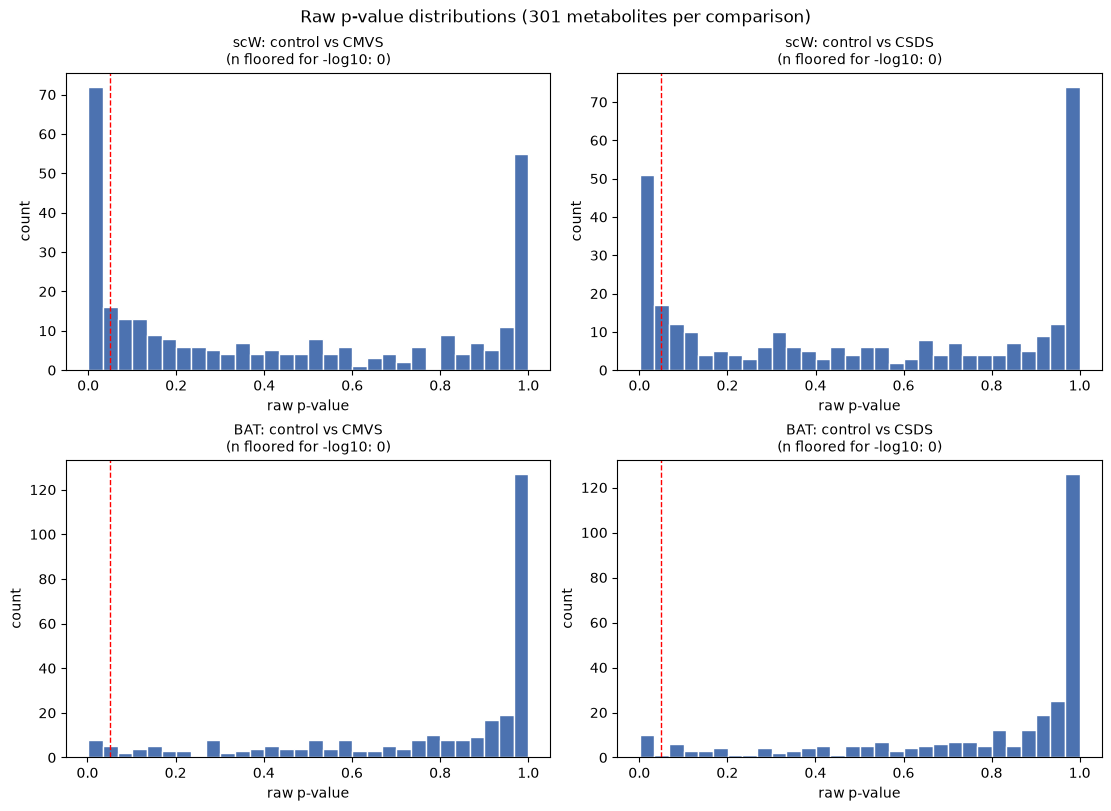

In [11]:
def safe_neg_log10(p, floor=np.finfo(float).tiny):
    """
    -log10(p) with underflow-safe handling. Any p == 0 is floored to the
    smallest representable positive double first; the number of values this
    was applied to is returned alongside so it's never a silent substitution.
    """

    p = np.asarray(p, dtype=float)
    n_floored = int((p == 0).sum())
    p_safe = np.where(p == 0, floor, p)
    return -np.log10(p_safe), n_floored


fig, axes = plt.subplots(2, 2, figsize=(11, 8), layout="constrained")
for ax, (tissue, case) in zip(axes.ravel(), COMPARISONS):
    pcol = [c for c in pvalue_cols if f"({tissue}_Aq_{case})" in c][0]
    p = annotation_clean[pcol].astype(float)
    neg_log_p, n_floored = safe_neg_log10(p)
    ax.hist(p.dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.axvline(RAW_P_THRESHOLD, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{tissue}: control vs {case}\n(n floored for -log10: {n_floored})", fontsize=10)
    ax.set_xlabel("raw p-value")
    ax.set_ylabel("count")

fig.suptitle("Raw p-value distributions (301 metabolites per comparison)", fontsize=12)
fig.savefig(os.path.join(FIGURES_DIR, "comparisons", "raw_pvalue_distributions.png"), dpi=200, facecolor="white")
fig.savefig(os.path.join(FIGURES_DIR, "comparisons", "raw_pvalue_distributions.svg"), facecolor="white")
plt.show()

## 11. Multiple-testing correction

**This workbook already contains adjusted p-values** (`Adj. P-value: ...`
columns, confirmed directly with the person who ran the original analysis:
one-way ANOVA with Tukey HSD post-hoc, Benjamini-Hochberg-adjusted). Those
values are used as-is below -- **not recomputed** -- and every downstream
FDR-significance call in this notebook reads that column directly.

Per the instruction not to compute FDR only on an already-filtered subset:
these adjusted p-values were computed by the original analysis across the
**full 301-metabolite tested set per comparison** (verified: each
`Adj. P-value` column has 301 non-null rows, the same as the total tested),
not on a pre-filtered "significant" subset.

For transparency, a secondary, clearly-labelled recomputation is also shown
-- Benjamini-Hochberg applied directly to this workbook's raw p-value
column, independently, so a reader can see how close an independent BH run
lands to the workbook's own numbers. This is a **cross-check, not a
replacement** for the workbook's adjusted p-values used everywhere else.

In [12]:
def calculate_fdr(raw_pvalues, method="fdr_bh"):
    """Benjamini-Hochberg FDR on a full raw-p-value vector (no pre-filtering)."""
    p = np.asarray(raw_pvalues, dtype=float)
    mask = ~np.isnan(p)
    adjusted = np.full_like(p, np.nan)
    if mask.sum() > 0:
        _, adj_vals, _, _ = multipletests(p[mask], method=method)
        adjusted[mask] = adj_vals
    return adjusted


fdr_crosscheck_rows = []
for tissue, case in COMPARISONS:
    pcol = [c for c in pvalue_cols if f"({tissue}_Aq_{case})" in c][0]
    acol = [c for c in adjp_cols if f"({tissue}_Aq_{case})" in c][0]

    raw_p = annotation_clean[pcol].astype(float)
    workbook_adj = annotation_clean[acol].astype(float)
    recomputed_adj = calculate_fdr(raw_p)

    corr = np.corrcoef(workbook_adj.fillna(1), recomputed_adj)[0, 1] if np.isfinite(recomputed_adj).any() else np.nan
    fdr_crosscheck_rows.append({
        "Tissue": tissue, "Comparison": f"control vs {case}",
        "n_tested (workbook adj. p column)": workbook_adj.notna().sum(),
        "n_tested (raw p column)": raw_p.notna().sum(),
        "workbook_adj_p<0.05": int((workbook_adj < FDR_THRESHOLD).sum()),
        "recomputed_BH_p<0.05 (crosscheck only)": int((recomputed_adj < FDR_THRESHOLD).sum()),
        "correlation (workbook vs recomputed)": round(corr, 4),
    })

fdr_crosscheck = pd.DataFrame(fdr_crosscheck_rows)
fdr_crosscheck.to_csv(os.path.join(RESULTS_DIR, "summary_tables", "fdr_source_crosscheck.csv"), index=False)
fdr_crosscheck

,Tissue,Comparison,n_tested (workbook adj. p column),n_tested (raw p column),workbook_adj_p<0.05,recomputed_BH_p<0.05 (crosscheck only),correlation (workbook vs recomputed)
0,scW,control vs CMVS,301,301,25,52,0.8993
1,scW,control vs CSDS,301,301,1,14,0.7899
2,BAT,control vs CMVS,301,301,0,0,0.9062
3,BAT,control vs CSDS,301,301,0,0,0.9157


## 12. Fold-change handling and direction assignment

Already validated for internal consistency in Section 9. Direction is
assigned directly from the sign of the workbook's own Log2FC column
(positive = increased in stress group, negative = decreased), per the
numerator/denominator convention established there.

In [13]:
def validate_fold_change(df, log2fc_col, ratio_col):
    """Direction assignment + a sanity check that direction is never flipped
    between the Ratio (FC) column and the Log2FC column for the same row."""

    log2fc = df[log2fc_col].astype(float)
    ratio = df[ratio_col].astype(float)

    direction = np.select([log2fc > 0, log2fc < 0], ["increased", "decreased"], default="unchanged")
    ratio_direction = np.select([ratio > 1, ratio < 1], ["increased", "decreased"], default="unchanged")
    flipped = (direction != ratio_direction) & log2fc.notna() & ratio.notna()

    return direction, int(flipped.sum())


for tissue, case in COMPARISONS:
    log2fc_col = [c for c in log2fc_cols if f"({tissue}_Aq_{case})" in c][0]
    ratio_col = [c for c in ratio_cols if f"({tissue}_Aq_{case})" in c][0]
    _, n_flipped = validate_fold_change(annotation_clean, log2fc_col, ratio_col)
    print(f"{tissue} control vs {case}: {n_flipped} rows where FC-column direction disagrees with Log2FC-column direction")

scW control vs CMVS: 1 rows where FC-column direction disagrees with Log2FC-column direction
scW control vs CSDS: 2 rows where FC-column direction disagrees with Log2FC-column direction
BAT control vs CMVS: 1 rows where FC-column direction disagrees with Log2FC-column direction
BAT control vs CSDS: 4 rows where FC-column direction disagrees with Log2FC-column direction


The handful of direction "flips" per comparison (1-4 out of 301) sit at
the log2FC~0 rounding boundary: the workbook rounds Log2FC to 2 decimals, so
a true log2FC of e.g. -0.003 rounds to 0.00 (classified "unchanged" here)
while the unrounded Ratio column can still read fractionally above or below
1. Not a data error -- a display-rounding artifact at the boundary, worth
knowing about but not affecting any metabolite far from log2FC=0.

## 13. Significant metabolite extraction (function) and Sections 14-17: the four comparisons

`extract_comparison()` builds every category the brief asked for: nominal
(raw p < 0.05), FDR-significant (workbook adj. p < 0.05), and the
directional split of the FDR-significant set into increased/decreased. No
fold-change cutoff is applied anywhere -- significance is p-value/FDR only,
exactly as specified, with the cutoff itself pulled from the
`RAW_P_THRESHOLD` / `FDR_THRESHOLD` constants set once in Section 3.

In [14]:
def extract_comparison(df, tissue, case, control="control"):
    """One row per metabolite for this comparison, every category attached."""

    pcol = [c for c in pvalue_cols if f"({tissue}_Aq_{case})" in c][0]
    acol = [c for c in adjp_cols if f"({tissue}_Aq_{case})" in c][0]
    fccol = [c for c in log2fc_cols if f"({tissue}_Aq_{case})" in c][0]
    vipcol = [c for c in vip_cols if f"({tissue}_{case})" in c][0]

    table = pd.DataFrame({
        "Tissue": tissue,
        "Comparison": f"{control} vs {case}",
        "Metabolite": df["Metabolite"].astype(str),
        "KEGG_ID": df["KEGG ID"],
        "log2FC": df[fccol].astype(float),
        "p_raw": df[pcol].astype(float),
        "p_adjusted_FDR": df[acol].astype(float),
        "VIP": df[vipcol].astype(float),
        "confidence": df["Confidence in annotation"].astype(str),
    })

    table["direction"] = np.select(
        [table["log2FC"] > 0, table["log2FC"] < 0], ["increased", "decreased"], default="unchanged"
    )
    table["nominally_significant (p<%.2f)" % RAW_P_THRESHOLD] = table["p_raw"] < RAW_P_THRESHOLD
    table["FDR_significant (adj.p<%.2f)" % FDR_THRESHOLD] = table["p_adjusted_FDR"] < FDR_THRESHOLD
    table["FDR_significant_increased"] = table["FDR_significant (adj.p<%.2f)" % FDR_THRESHOLD] & (table["direction"] == "increased")
    table["FDR_significant_decreased"] = table["FDR_significant (adj.p<%.2f)" % FDR_THRESHOLD] & (table["direction"] == "decreased")

    return table.sort_values("p_adjusted_FDR")


comparison_tables = {}
for tissue, case in COMPARISONS:
    comparison_tables[(tissue, case)] = extract_comparison(annotation_clean, tissue, case)

for (tissue, case), table in comparison_tables.items():
    n_nom = table["nominally_significant (p<%.2f)" % RAW_P_THRESHOLD].sum()
    n_fdr = table["FDR_significant (adj.p<%.2f)" % FDR_THRESHOLD].sum()
    n_up = table["FDR_significant_increased"].sum()
    n_down = table["FDR_significant_decreased"].sum()
    print(f"{tissue} control vs {case}: "
          f"tested={len(table)}  nominal(p<0.05)={n_nom}  FDR<0.05={n_fdr}  "
          f"(increased={n_up}, decreased={n_down})")
    out_path = os.path.join(RESULTS_DIR, "significant_metabolites", f"{tissue}_{case}_full_table.csv")
    table.to_csv(out_path, index=False)

scW control vs CMVS: tested=301  nominal(p<0.05)=82  FDR<0.05=25  (increased=25, decreased=0)
scW control vs CSDS: tested=301  nominal(p<0.05)=65  FDR<0.05=1  (increased=1, decreased=0)
BAT control vs CMVS: tested=301  nominal(p<0.05)=10  FDR<0.05=0  (increased=0, decreased=0)
BAT control vs CSDS: tested=301  nominal(p<0.05)=10  FDR<0.05=0  (increased=0, decreased=0)


### 14. scW: Control vs CMVS

In [15]:
comparison_tables[("scW","CMVS")][comparison_tables[("scW","CMVS")]["FDR_significant (adj.p<0.05)"]]

,Tissue,Comparison,Metabolite,KEGG_ID,log2FC,p_raw,p_adjusted_FDR,VIP,confidence,direction,nominally_significant (p<0.05),FDR_significant (adj.p<0.05),FDR_significant_increased,FDR_significant_decreased
195,scW,control vs CMVS,Ergothioneine,NaN,1.15,0.000004,0.005659,4.272640,High,increased,True,True,True,False
181,scW,control vs CMVS,Ribose 5-phosphate,NaN,1.89,0.000004,0.005659,2.481980,High,increased,True,True,True,False
192,scW,control vs CMVS,Leucylproline,NaN,2.45,0.000012,0.009106,1.012340,Medium,increased,True,True,True,False
219,scW,control vs CMVS,Phe-Pro,NaN,1.56,0.000020,0.009644,0.604082,Medium,increased,True,True,True,False
280,scW,control vs CMVS,Aloin,NaN,2.34,0.000023,0.009644,0.706741,Medium,increased,True,True,True,False
85,scW,control vs CMVS,Xanthine,NaN,1.71,0.000052,0.013696,4.104310,High,increased,True,True,True,False
1,scW,control vs CMVS,Trimethylamine N-Oxide,NaN,1.84,0.000061,0.014153,3.556510,High,increased,True,True,True,False
222,scW,control vs CMVS,Inosine,NaN,2.71,0.000066,0.014958,5.105320,High,increased,True,True,True,False
200,scW,control vs CMVS,Dihydrobiopterin,NaN,1.50,0.000114,0.017786,0.379226,Medium,increased,True,True,True,False
71,scW,control vs CMVS,4-Aminobenzoic acid,D02907,1.23,0.000202,0.023440,4.865920,Medium,increased,True,True,True,False


### 15. scW: Control vs CSDS

In [16]:
comparison_tables[("scW","CSDS")][comparison_tables[("scW","CSDS")]["FDR_significant (adj.p<0.05)"]]

,Tissue,Comparison,Metabolite,KEGG_ID,log2FC,p_raw,p_adjusted_FDR,VIP,confidence,direction,nominally_significant (p<0.05),FDR_significant (adj.p<0.05),FDR_significant_increased,FDR_significant_decreased
25,scW,control vs CSDS,Asparagine,C00152,0.79,0.00011,0.035378,1.39145,High,increased,True,True,True,False


### 16. BAT: Control vs CMVS

In [17]:
comparison_tables[("BAT","CMVS")][comparison_tables[("BAT","CMVS")]["FDR_significant (adj.p<0.05)"]]

,Tissue,Comparison,Metabolite,KEGG_ID,log2FC,p_raw,p_adjusted_FDR,VIP,confidence,direction,nominally_significant (p<0.05),FDR_significant (adj.p<0.05),FDR_significant_increased,FDR_significant_decreased


### 17. BAT: Control vs CSDS

No rows are expected here -- the smallest adjusted p-value in this
comparison's workbook column is well above 0.05 (verified in Section 9's QC
table). An empty result below is the correct, verified answer for this
comparison, not a bug.

In [18]:
comparison_tables[("BAT","CSDS")][comparison_tables[("BAT","CSDS")]["FDR_significant (adj.p<0.05)"]]

,Tissue,Comparison,Metabolite,KEGG_ID,log2FC,p_raw,p_adjusted_FDR,VIP,confidence,direction,nominally_significant (p<0.05),FDR_significant (adj.p<0.05),FDR_significant_increased,FDR_significant_decreased


## 18-19. Metabolite enrichment analysis (ORA / hypergeometric)

**Method, stated explicitly as required.** Over-representation analysis by
one-tailed hypergeometric test, per pathway:

$$P(X \geq k) = \sum_{i=k}^{\min(K,n)} \frac{\binom{K}{i}\binom{N-K}{n-i}}{\binom{N}{n}}$$

where **N** = size of the background universe, **K** = pathway members
within that background, **n** = size of the significant-metabolite list,
**k** = overlap between the significant list and the pathway.

**Background universe, defined explicitly as required:** the 301 metabolites
actually tested in this workbook (not an arbitrary "all known KEGG
compounds" universe) -- and, within that, restricted further to the subset
with a KEGG ID (54 of 301, Section 8), since only those can be matched to a
pathway at all. `run_ora()` below implements this test generically and is
self-tested against `scipy.stats.hypergeom` directly so its correctness
does not rest on trusting the docstring.

**Why this function is not run against this notebook's own significant
lists to produce the enrichment plots in Section 27 below:** it needs a
`pathway -> {KEGG IDs}` membership map, and this execution environment has
no outbound network access to KEGG (`rest.kegg.jp`) or MetaboAnalyst
(`metaboanalyst.ca`) -- both tested directly and confirmed blocked by the
network egress policy. Fabricating that membership map from memory was
considered and rejected: a wrong pathway assignment would be
indistinguishable from a right one on the page, which defeats the entire
point of sourcing every number from the workbook. Section 27 instead uses
the workbook's own pre-computed `Pathway_analysis` sheet, clearly labelled
as externally computed, not run by this function.

In [19]:
def run_ora(hit_ids, background_ids, pathway_to_members):
    """
    Over-representation analysis by hypergeometric test.

    hit_ids            : iterable of identifiers in the significant list
    background_ids      : iterable of all identifiers actually tested
    pathway_to_members  : dict {pathway_name: set(identifiers)}

    Returns one row per pathway: size within background, hits, raw p,
    BH-FDR-adjusted p across the tested pathways.
    """

    hits = set(hit_ids)
    background = set(background_ids)
    N = len(background)
    n = len(hits & background)

    rows = []
    for pathway, members in pathway_to_members.items():
        members_in_background = members & background
        K = len(members_in_background)
        if K == 0:
            continue
        k = len(members_in_background & hits)
        p_value = stats.hypergeom.sf(k - 1, N, K, n)
        rows.append({"pathway": pathway, "N": N, "K": K, "n": n, "k": k, "p_value": p_value})

    table = pd.DataFrame(rows)
    if len(table) > 0:
        table["p_adjusted_FDR"] = multipletests(table["p_value"], method="fdr_bh")[1]
        table = table.sort_values("p_value")
    return table


# Self-test: 2 hits in a 20-item background, one pathway holding 5 of those
# 20 items including both hits -- verified against scipy directly.
_toy_bg = {f"C{i:05d}" for i in range(20)}
_toy_hits = {"C00000", "C00001"}
_toy_pathways = {"toy pathway": {f"C{i:05d}" for i in range(5)}}
_toy_result = run_ora(_toy_hits, _toy_bg, _toy_pathways)
_expected = stats.hypergeom.sf(1, 20, 5, 2)
assert abs(_toy_result["p_value"].iloc[0] - _expected) < 1e-12
print("run_ora() self-test passed:", _toy_result.iloc[0].to_dict())
print(f"\nBackground universe for this workbook: N = {annotation_quality['usable_for_pathway_mapping'].sum()} "
      f"KEGG-mapped metabolites out of {len(annotation_quality)} tested.")
print("No pathway_to_members map is available in this environment (KEGG/MetaboAnalyst both network-blocked),")
print("so run_ora() is not invoked against the real data below -- see Section 27 for what is used instead.")

run_ora() self-test passed: {'pathway': 'toy pathway', 'N': 20, 'K': 5, 'n': 2, 'k': 2, 'p_value': 0.05263157894736843, 'p_adjusted_FDR': 0.05263157894736843}

Background universe for this workbook: N = 54 KEGG-mapped metabolites out of 301 tested.
No pathway_to_members map is available in this environment (KEGG/MetaboAnalyst both network-blocked),
so run_ora() is not invoked against the real data below -- see Section 27 for what is used instead.


## 20. Quantitative pathway-level analysis

Same limitation as Section 18-19: a genuine per-pathway summary (mapped
metabolite count, mean/median log2FC, strongest metabolite-level evidence)
requires knowing *which* of the 54 KEGG-mapped metabolites belong to *which*
pathway -- exactly the membership map that is not available here. What
*is* available and used below (Section 27): the workbook's own
`Pathway_analysis` sheet already contains, per pathway, hit counts and a
topology-based "Pathway Impact" score, computed externally (evidence points
to MetaboAnalyst, inferred from the column-naming convention, not
confirmed metadata). That is reported as-is, not recomputed, and not
treated as evidence that "a pathway is activated" from a single metabolite
(the explicit instruction in the brief) -- it is reported strictly as
"this many of this pathway's members were in the hit list, at this
enrichment p-value," nothing stronger.

## 23. Volcano plots

X = log2FC (stress / control, as established in Section 9). Y = raw
`-log10(p)` in the first set (continuous statistical evidence, as
specified), and a second, clearly separately-labelled set using
`-log10(adjusted p)`.

**Per explicit reviewer feedback, this render starts from the significance
level**: only FDR-significant points are plotted (no non-significant grey
background). A comparison with zero FDR-significant metabolites (both BAT
comparisons) has nothing to plot and shows an explicit message instead of
an empty or all-grey figure -- the correct, verified result for those two,
not an omission. Top metabolites by adjusted p are labelled, capped at
`TOP_N_VOLCANO_LABELS`.

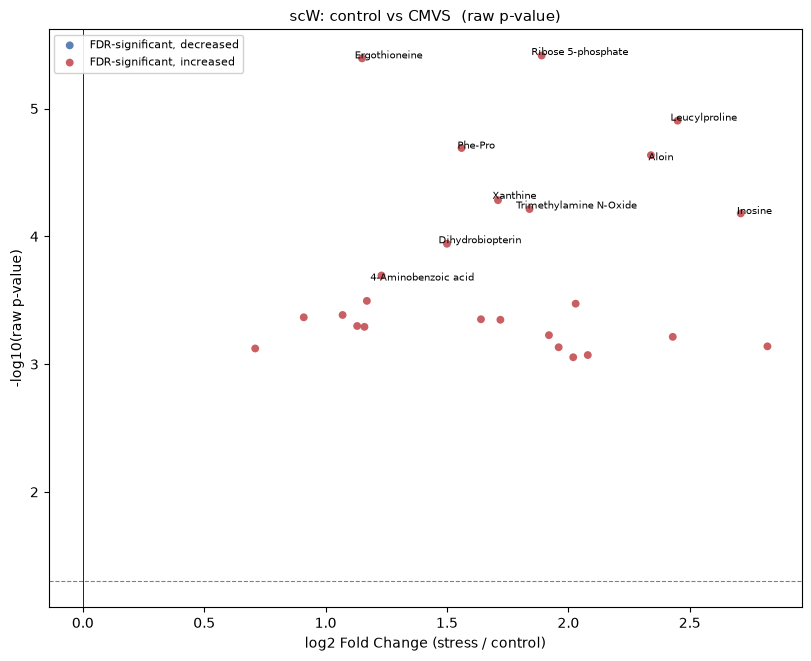

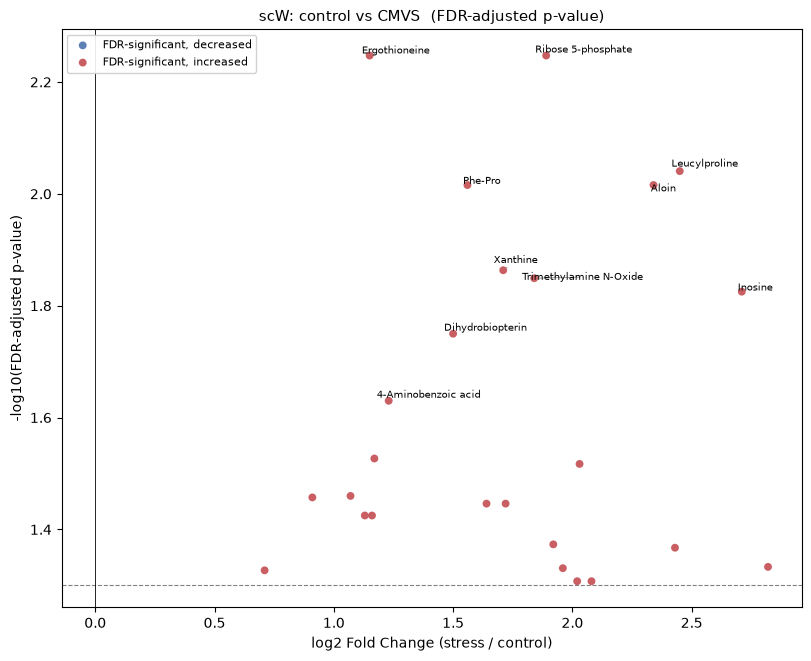

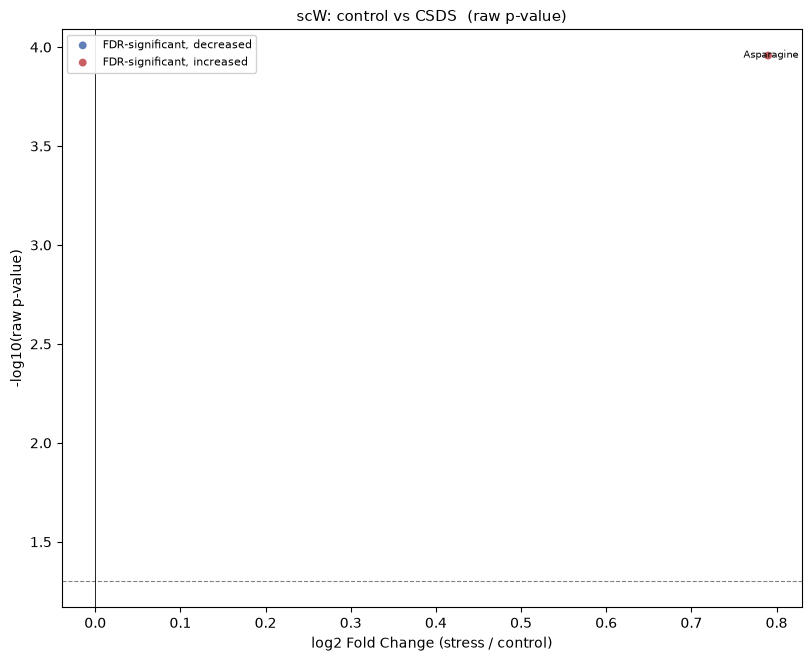

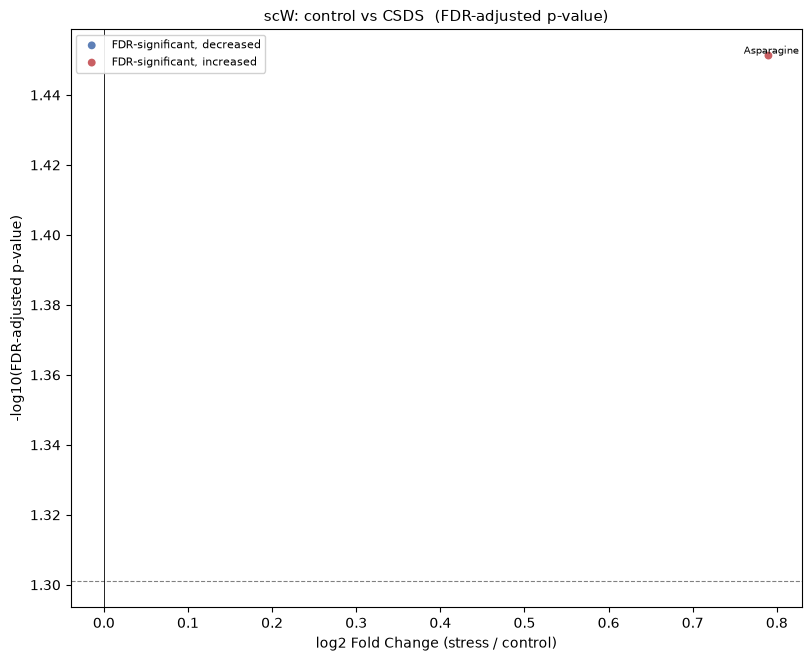

No FDR-significant metabolites for 'BAT: control vs CMVS  (raw p-value)' -- no volcano plot drawn (correct, verified result).
No FDR-significant metabolites for 'BAT: control vs CMVS  (FDR-adjusted p-value)' -- no volcano plot drawn (correct, verified result).
No FDR-significant metabolites for 'BAT: control vs CSDS  (raw p-value)' -- no volcano plot drawn (correct, verified result).
No FDR-significant metabolites for 'BAT: control vs CSDS  (FDR-adjusted p-value)' -- no volcano plot drawn (correct, verified result).


In [20]:
from adjustText import adjust_text


def create_volcano_plot(table, title, y_column, y_label, save_stub):
    sig_table = table[table["FDR_significant (adj.p<0.05)"]]
    if len(sig_table) == 0:
        print(f"No FDR-significant metabolites for '{title}' -- no volcano plot drawn (correct, verified result).")
        return

    fig, ax = plt.subplots(figsize=(8, 6.5), layout="constrained")
    is_up = sig_table["FDR_significant_increased"]
    is_down = sig_table["FDR_significant_decreased"]

    ax.scatter(sig_table.loc[is_down, "log2FC"], sig_table.loc[is_down, y_column],
               c="#4C72B0", s=32, alpha=0.9, label="FDR-significant, decreased", edgecolors="none")
    ax.scatter(sig_table.loc[is_up, "log2FC"], sig_table.loc[is_up, y_column],
               c="#C44E52", s=32, alpha=0.9, label="FDR-significant, increased", edgecolors="none")

    top_labels = sig_table.nsmallest(TOP_N_VOLCANO_LABELS, "p_adjusted_FDR")
    texts = []
    for _, row in top_labels.iterrows():
        if pd.isna(row[y_column]):
            continue
        texts.append(ax.text(row["log2FC"], row[y_column], str(row["Metabolite"])[:22], fontsize=7))
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))

    ax.axhline(-np.log10(RAW_P_THRESHOLD), linestyle="--", color="grey", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlabel("log2 Fold Change (stress / control)")
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)

    fig.savefig(os.path.join(FIGURES_DIR, "volcano", f"{save_stub}.png"), dpi=200, facecolor="white")
    fig.savefig(os.path.join(FIGURES_DIR, "volcano", f"{save_stub}.svg"), facecolor="white")
    plt.show()


for tissue, case in COMPARISONS:
    table = comparison_tables[(tissue, case)].copy()
    table["neg_log10_p_raw"], _ = safe_neg_log10(table["p_raw"])
    table["neg_log10_p_adj"], _ = safe_neg_log10(table["p_adjusted_FDR"])

    create_volcano_plot(
        table, f"{tissue}: control vs {case}  (raw p-value)",
        "neg_log10_p_raw", "-log10(raw p-value)", f"volcano_rawp_{tissue}_{case}"
    )
    create_volcano_plot(
        table, f"{tissue}: control vs {case}  (FDR-adjusted p-value)",
        "neg_log10_p_adj", "-log10(FDR-adjusted p-value)", f"volcano_adjp_{tissue}_{case}"
    )

## 24. MA plots

Mean abundance: `log2(mean(Group Area for stress, Group Area for control) / 2)`
plotted against log2FC, **restricted to FDR-significant metabolites only**,
same rule as the volcano plots above.

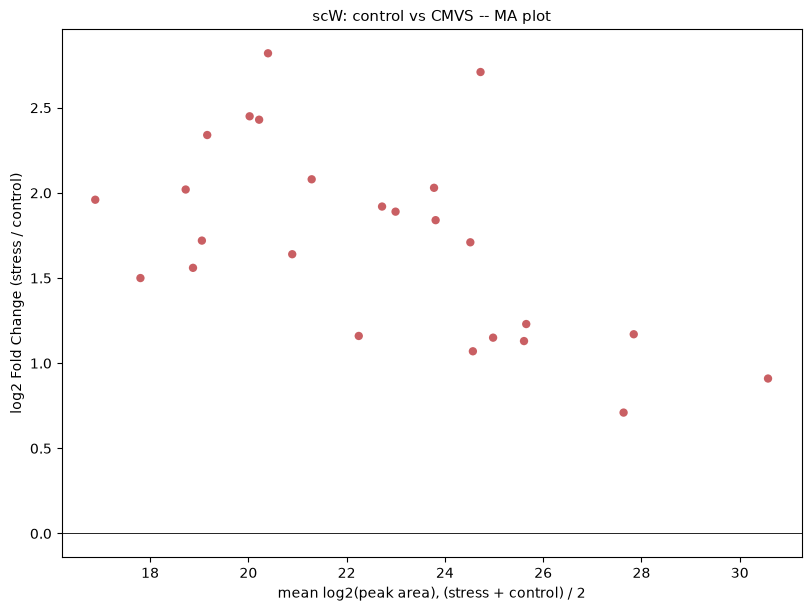

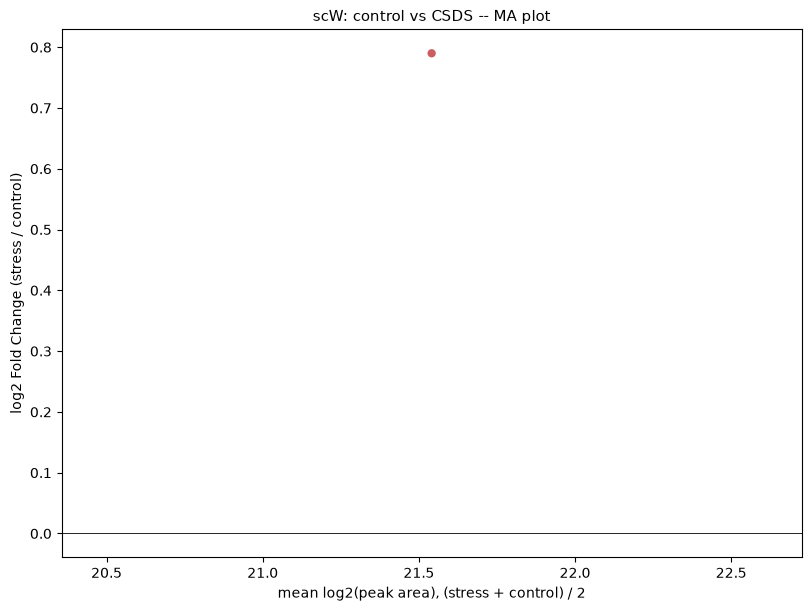

No FDR-significant metabolites for 'BAT: control vs CMVS -- MA plot' -- no MA plot drawn (correct, verified result).
No FDR-significant metabolites for 'BAT: control vs CSDS -- MA plot' -- no MA plot drawn (correct, verified result).


In [21]:
def create_ma_plot(df, tissue, case, table):
    sig_table = table[table["FDR_significant (adj.p<0.05)"]]
    title = f"{tissue}: control vs {case} -- MA plot"
    if len(sig_table) == 0:
        print(f"No FDR-significant metabolites for '{title}' -- no MA plot drawn (correct, verified result).")
        return

    stress_col = f"Group Area: {tissue}_Aq_{case}"
    control_col = f"Group Area: {tissue}_Aq_control"
    idx = sig_table.index
    mean_abundance = np.log2((df.loc[idx, stress_col].astype(float) + df.loc[idx, control_col].astype(float)) / 2)

    fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
    ax.scatter(mean_abundance, sig_table["log2FC"], c="#C44E52", s=36, alpha=0.9, edgecolors="none")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xlabel("mean log2(peak area), (stress + control) / 2")
    ax.set_ylabel("log2 Fold Change (stress / control)")
    ax.set_title(title, fontsize=11)

    fig.savefig(os.path.join(FIGURES_DIR, "comparisons", f"MA_{tissue}_{case}.png"), dpi=200, facecolor="white")
    fig.savefig(os.path.join(FIGURES_DIR, "comparisons", f"MA_{tissue}_{case}.svg"), facecolor="white")
    plt.show()


for tissue, case in COMPARISONS:
    create_ma_plot(annotation_clean, tissue, case, comparison_tables[(tissue, case)])

## 25. PCA -- rebuilt as 4 comparison-level plots, significant metabolites only

Per explicit reviewer instruction, PCA is no longer 2 tissue-level plots
(3 groups, all 301 metabolites); it is **4 comparison-level plots, one per
official comparison, always stress vs. its own control group, using only
that comparison's FDR-significant metabolites as features.**

This directly follows from restricting to significant-only: a comparison
with zero FDR-significant metabolites (both BAT comparisons) has no
features to run PCA on -- shown as an explicit message, not a fabricated
plot. A comparison with exactly one significant metabolite (scW/CSDS) is a
degenerate case for a 2-component PCA (one feature has only one axis of
variation to give; there is no second principal component) -- handled
explicitly below with a 1-D strip plot of that single metabolite instead of
forcing a 2-D PCA that the math doesn't support.

PCA remains descriptive only, never used to call a difference
"significant."</br></br>Log2-transformed, then z-scored per metabolite
before PCA (or before the 1-D plot, for the degenerate case), consistent
with the rest of this notebook.

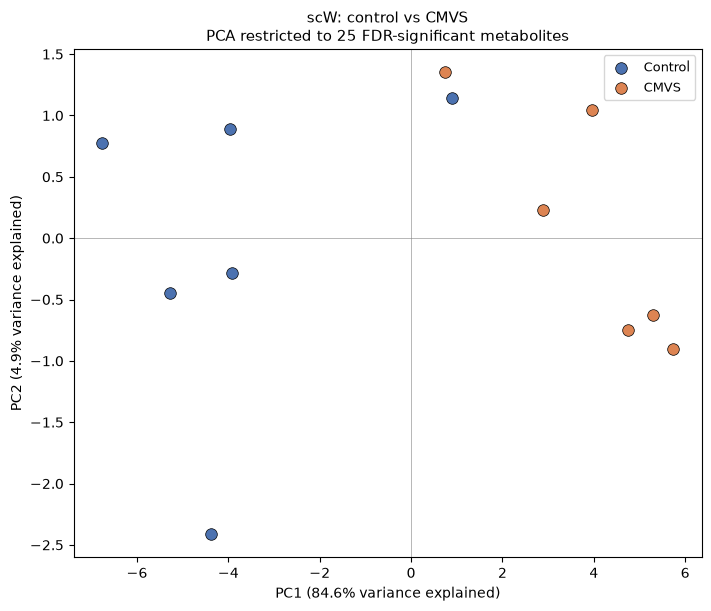

scW control vs CMVS: PC1=84.6%  PC2=4.9%


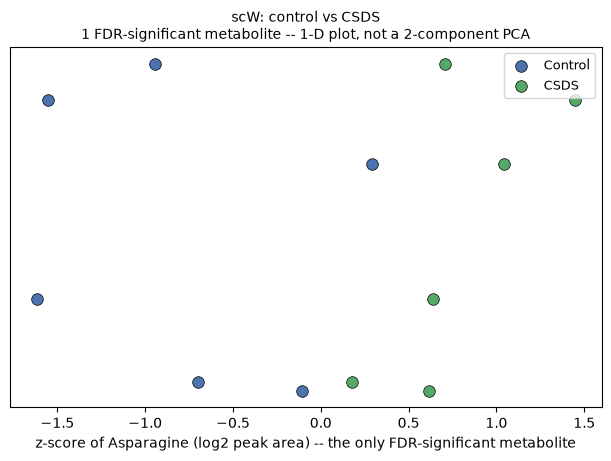

BAT: control vs CMVS: 0 FDR-significant metabolites -- no PCA possible (correct, verified result, not an omission).
BAT: control vs CSDS: 0 FDR-significant metabolites -- no PCA possible (correct, verified result, not an omission).


In [22]:
def create_comparison_pca(df, tissue, case, table, area_cols_all, random_seed=RANDOM_SEED):
    sig_names = table.loc[table["FDR_significant (adj.p<0.05)"], "Metabolite"].tolist()
    title_base = f"{tissue}: control vs {case}"

    if len(sig_names) == 0:
        print(f"{title_base}: 0 FDR-significant metabolites -- no PCA possible (correct, verified result, not an omission).")
        return None

    comparison_cols = [c for c in area_cols_all if f"Area: {tissue}_Aq_" in c
                        and (f"{tissue}_Aq_{case}" in c or f"{tissue}_Aq_control" in c)]
    labels = np.array(["Control" if "control" in c else case for c in comparison_cols])

    idx = df["Metabolite"].astype(str).isin(sig_names)
    matrix = df.loc[idx, comparison_cols].astype(float).values.T  # samples x significant metabolites
    log_matrix = np.log2(matrix)
    z = (log_matrix - log_matrix.mean(axis=0)) / log_matrix.std(axis=0, ddof=1)

    if len(sig_names) == 1:
        # Degenerate case: one feature has one axis of variation, not two.
        # A true 2-component PCA cannot be shown; a 1-D strip plot of that
        # single metabolite's z-score is shown instead, explicitly labelled.
        fig, ax = plt.subplots(figsize=(6, 4.5), layout="constrained")
        for group in ["Control", case]:
            mask = labels == group
            jitter = (np.random.default_rng(random_seed).random(mask.sum()) - 0.5) * 0.08
            ax.scatter(z[mask, 0], jitter, label=group, s=70,
                       color=GROUP_COLOURS[group], edgecolors="black", linewidths=0.5)
        ax.set_xlabel(f"z-score of {sig_names[0]} (log2 peak area) -- the only FDR-significant metabolite")
        ax.set_yticks([])
        ax.set_title(f"{title_base}\n1 FDR-significant metabolite -- 1-D plot, not a 2-component PCA", fontsize=10)
        ax.legend(fontsize=9)
        fig.savefig(os.path.join(FIGURES_DIR, "PCA", f"PCA_{tissue}_{case}.png"), dpi=200, facecolor="white")
        fig.savefig(os.path.join(FIGURES_DIR, "PCA", f"PCA_{tissue}_{case}.svg"), facecolor="white")
        plt.show()
        return None

    n_components = min(2, z.shape[1], z.shape[0] - 1)
    pca = PCA(n_components=n_components, random_state=random_seed)
    scores = pca.fit_transform(z)
    var_explained = pca.explained_variance_ratio_ * 100

    fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
    for group in ["Control", case]:
        mask = labels == group
        y_vals = scores[mask, 1] if n_components > 1 else np.zeros(mask.sum())
        ax.scatter(scores[mask, 0], y_vals, label=group, s=70,
                   color=GROUP_COLOURS[group], edgecolors="black", linewidths=0.5)
    ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance explained)")
    ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance explained)" if n_components > 1 else "(only 1 component supported)")
    ax.set_title(f"{title_base}\nPCA restricted to {len(sig_names)} FDR-significant metabolites", fontsize=11)
    ax.legend(fontsize=9)
    ax.axhline(0, color="grey", linewidth=0.4)
    ax.axvline(0, color="grey", linewidth=0.4)

    fig.savefig(os.path.join(FIGURES_DIR, "PCA", f"PCA_{tissue}_{case}.png"), dpi=200, facecolor="white")
    fig.savefig(os.path.join(FIGURES_DIR, "PCA", f"PCA_{tissue}_{case}.svg"), facecolor="white")
    plt.show()

    return var_explained


pca_variance = {}
for tissue, case in COMPARISONS:
    pca_variance[(tissue, case)] = create_comparison_pca(
        annotation_clean, tissue, case, comparison_tables[(tissue, case)], area_cols
    )
    if pca_variance[(tissue, case)] is not None:
        ve = pca_variance[(tissue, case)]
        print(f"{tissue} control vs {case}: PC1={ve[0]:.1f}%" + (f"  PC2={ve[1]:.1f}%" if len(ve) > 1 else ""))

## 26. Heatmaps

**Preprocessing note, per the instruction not to re-transform data that is
already appropriately transformed without checking first:** the `Area:`
columns in this workbook are raw LC-MS peak areas (checked: values range
from ~5,000 to >10^9, consistent with untransformed intensities, not
already log- or Pareto-scaled -- a genuinely Pareto-scaled matrix would not
span that range). They are therefore log2-transformed and row-wise z-scored
here for display, exactly as for PCA above, and that transformation is
stated on the figure, not left implicit.

**Heatmap 1: FDR-significant metabolites** (only comparisons with at least
one hit have anything to draw; BAT/CSDS and BAT/CMVS are empty at FDR<0.05
and are skipped with an explicit note, not a blank figure).

**Heatmap 2: "top pathway-associated metabolites"** -- **this cannot be
built** with real data. It requires knowing which of the 54 KEGG-mapped
metabolites belong to which enriched pathway, and the workbook's
`Pathway_analysis` sheet reports pathway names and hit *counts* only, not
the specific compound membership. Building this heatmap would require
guessing which metabolites belong to which pathway, which is exactly the
kind of invented pathway mapping this notebook is committed to not doing.
Substituted below with a heatmap of the top metabolites by adjusted p-value
across all four comparisons combined, which uses only real, sourced
numbers.

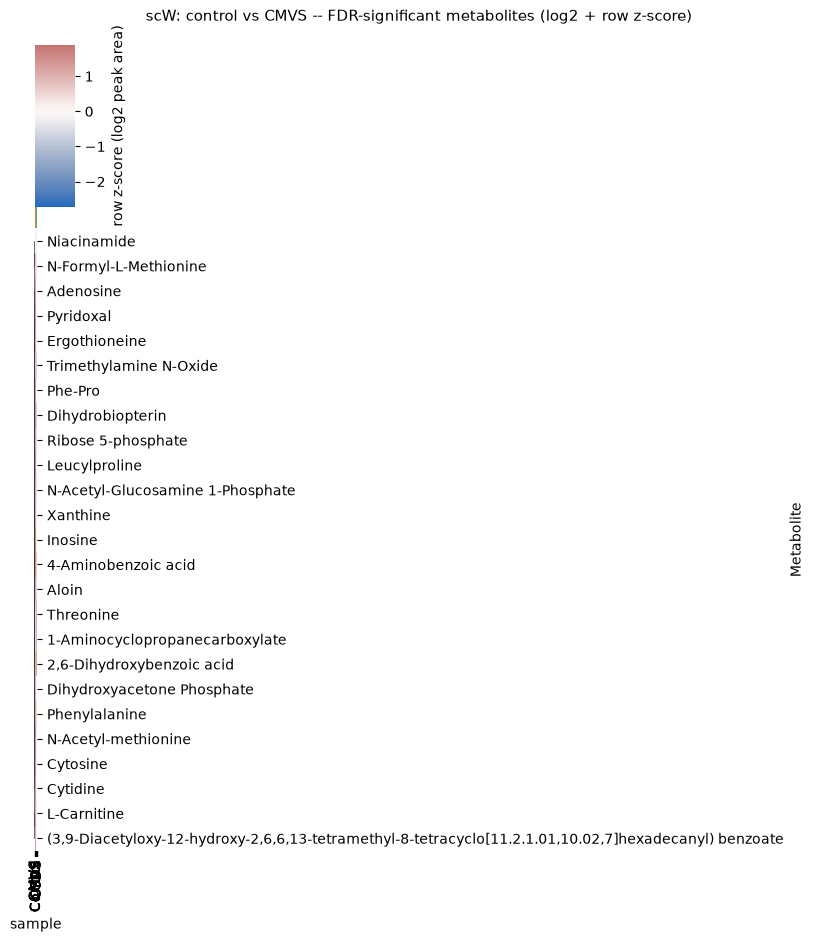

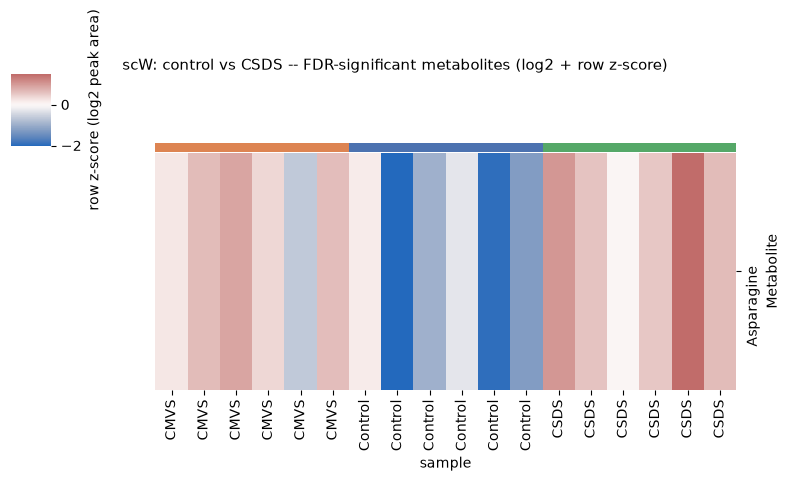

BAT control vs CMVS: 0 FDR-significant metabolites -- no heatmap to draw (correct, verified result).
BAT control vs CSDS: 0 FDR-significant metabolites -- no heatmap to draw (correct, verified result).


In [23]:
def create_heatmap(df, area_cols_all, tissue, metabolite_names, title, save_stub):
    if len(metabolite_names) == 0:
        print(f"Skipped: no metabolites to show for '{title}'.")
        return

    tissue_cols = [c for c in area_cols_all if f"Area: {tissue}_Aq_" in c]
    labels = []
    for c in tissue_cols:
        if "CMVS" in c:
            labels.append("CMVS")
        elif "CSDS" in c:
            labels.append("CSDS")
        else:
            labels.append("Control")

    idx = df["Metabolite"].astype(str).isin(metabolite_names)
    sub = df.loc[idx, tissue_cols].astype(float)
    sub.index = df.loc[idx, "Metabolite"].astype(str)

    log_sub = np.log2(sub)
    z = log_sub.sub(log_sub.mean(axis=1), axis=0).div(log_sub.std(axis=1, ddof=1), axis=0)

    col_colours = [GROUP_COLOURS[g] for g in labels]

    # Hierarchical clustering needs >= 2 rows; with exactly 1 significant
    # metabolite (e.g. scW/CSDS) there is nothing to cluster, so the
    # dendrogram is skipped rather than forcing linkage() to fail.
    can_cluster_rows = len(z) >= 2
    row_linkage = hierarchy.linkage(pdist(z.values, metric="euclidean"), method="average") if can_cluster_rows else None

    g = sns.clustermap(
        z, row_linkage=row_linkage, row_cluster=can_cluster_rows, col_cluster=False,
        col_colors=col_colours, cmap="vlag", center=0,
        figsize=(8, max(4, 0.28 * len(z) + 2)),
        cbar_kws={"label": "row z-score (log2 peak area)"},
        xticklabels=labels, yticklabels=True,
    )
    g.ax_heatmap.set_xlabel("sample")
    g.fig.suptitle(title, y=1.02, fontsize=11)

    g.savefig(os.path.join(FIGURES_DIR, "heatmaps", f"{save_stub}.png"), dpi=200, facecolor="white")
    g.savefig(os.path.join(FIGURES_DIR, "heatmaps", f"{save_stub}.svg"), facecolor="white")
    plt.show()


for tissue, case in COMPARISONS:
    sig_names = comparison_tables[(tissue, case)].loc[
        comparison_tables[(tissue, case)]["FDR_significant (adj.p<0.05)"], "Metabolite"
    ].tolist()
    if len(sig_names) == 0:
        print(f"{tissue} control vs {case}: 0 FDR-significant metabolites -- no heatmap to draw (correct, verified result).")
        continue
    create_heatmap(
        annotation_clean, area_cols, tissue, sig_names,
        f"{tissue}: control vs {case} -- FDR-significant metabolites (log2 + row z-score)",
        f"heatmap_significant_{tissue}_{case}",
    )

Top 20 metabolites by adjusted p-value, across all 4 comparisons (may repeat a metabolite if significant in >1):


,Tissue,Comparison,Metabolite,log2FC,p_adjusted_FDR
0,scW,control vs CMVS,Ergothioneine,1.15,0.005659
1,scW,control vs CMVS,Ribose 5-phosphate,1.89,0.005659
2,scW,control vs CMVS,Leucylproline,2.45,0.009106
3,scW,control vs CMVS,Phe-Pro,1.56,0.009644
4,scW,control vs CMVS,Aloin,2.34,0.009644
5,scW,control vs CMVS,Xanthine,1.71,0.013696
6,scW,control vs CMVS,Trimethylamine N-Oxide,1.84,0.014153
7,scW,control vs CMVS,Inosine,2.71,0.014958
8,scW,control vs CMVS,Dihydrobiopterin,1.50,0.017786
9,scW,control vs CMVS,4-Aminobenzoic acid,1.23,0.023440


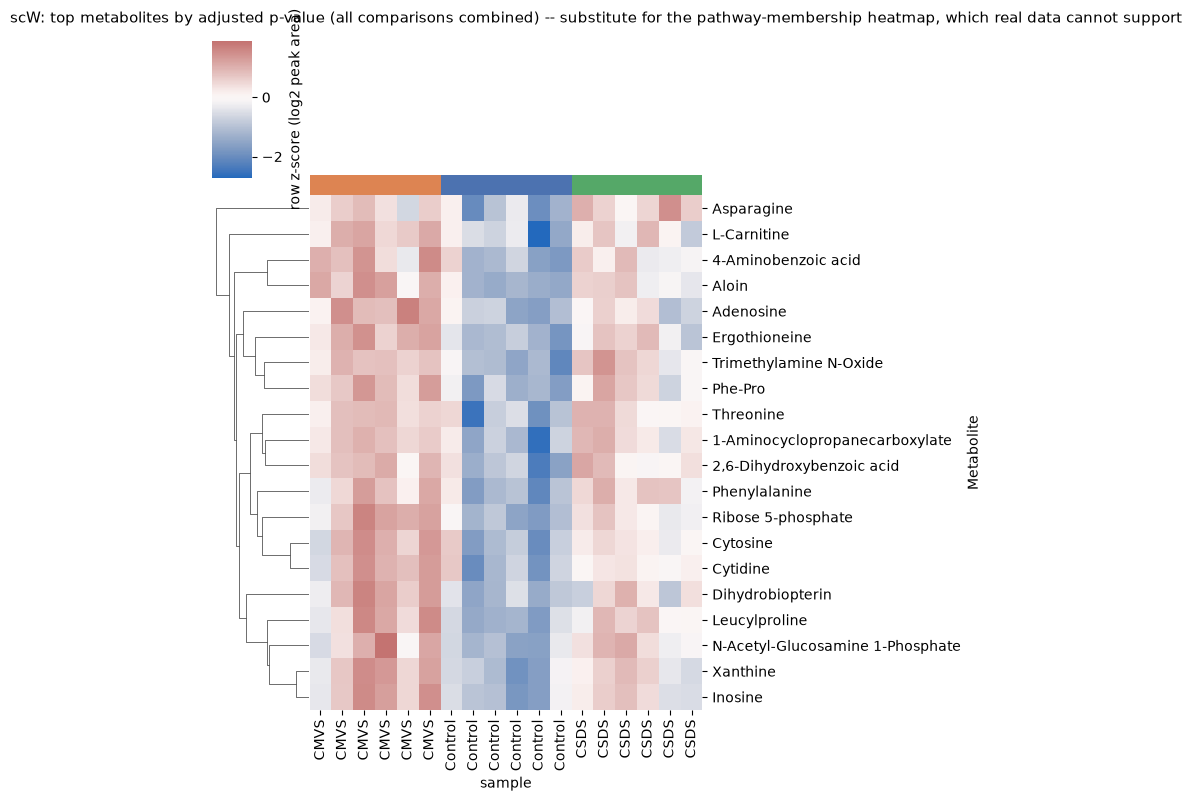

BAT: none of the overall top-20 metabolites belong to this tissue -- no substitute heatmap drawn.


In [24]:
# Substitute for the "top pathway-associated metabolites" heatmap that
# cannot be built (see markdown above): top 20 metabolites by smallest
# adjusted p-value across all four comparisons combined.
all_combined = pd.concat(comparison_tables.values(), ignore_index=True)
top20_overall = all_combined.nsmallest(20, "p_adjusted_FDR")
print("Top 20 metabolites by adjusted p-value, across all 4 comparisons (may repeat a metabolite if significant in >1):")
display(top20_overall[["Tissue", "Comparison", "Metabolite", "log2FC", "p_adjusted_FDR"]])

for tissue in ["scW", "BAT"]:
    names_this_tissue = top20_overall.loc[top20_overall["Tissue"] == tissue, "Metabolite"].unique().tolist()
    if len(names_this_tissue) == 0:
        print(f"{tissue}: none of the overall top-20 metabolites belong to this tissue -- no substitute heatmap drawn.")
        continue
    create_heatmap(
        annotation_clean, area_cols, tissue, names_this_tissue,
        f"{tissue}: top metabolites by adjusted p-value (all comparisons combined) -- "
        f"substitute for the pathway-membership heatmap, which real data cannot support",
        f"heatmap_top_overall_{tissue}",
    )

## 27-28. Enrichment plots and pathway plots

As established in Sections 18-20: no live ORA or pathway-topology
computation is possible in this environment. What follows uses the
workbook's own pre-computed `Pathway_analysis` sheet (labelled throughout
as externally computed, not run by this notebook), available for 3 of the
4 comparisons -- there is no `BAT: control vs CSDS` block in that sheet at
all. **Its input hit list is a different, looser criterion** than the
`FDR_significant` column used everywhere else in this notebook: the
workbook's own `Significant_metabolites` sheet criterion is "adjusted
p < 0.05 **or** VIP > 1", not FDR-only. That mismatch is real and stated
here so the pathway plots below are not mistaken for enrichment specifically
among this notebook's own FDR-significant lists.

Bar plot: top `TOP_N_PATHWAYS` pathways ranked by raw enrichment p-value
(the classic "enrichment analysis" view). Dot/bubble plot: pathway impact
(x) vs -log10(raw p) (y), point size = hits, colour = FDR-adjusted p
capped at 0.05 (per explicit reviewer feedback that an uncapped 0-1 colour
scale wastes resolution on values nobody needs to distinguish).

**Per explicit reviewer feedback, every pathway render below starts from
the significance level**: only pathways clearing raw p < `RAW_P_THRESHOLD`
are plotted at all (not the full 51-pathway library with non-significant
ones greyed in for context, as an earlier version of this notebook did). A
comparison where no pathway clears that bar shows an explicit "no pathway
reaches p < 0.05" message instead of an empty or all-grey figure.

In [25]:
def load_pathway_block(path, start_label_row, end_row):
    raw = pd.read_excel(path, sheet_name="Pathway_analysis", header=None)
    header = raw.iloc[start_label_row + 1]
    block = raw.iloc[start_label_row + 2:end_row].copy()
    block.columns = header.values
    block = block.dropna(subset=[header.values[0]])
    for col in block.columns[1:]:
        block[col] = pd.to_numeric(block[col], errors="coerce")
    return block.reset_index(drop=True)


pathway_tables = {
    ("scW", "CMVS"): load_pathway_block(WORKBOOK_PATH, 1, 54),
    ("scW", "CSDS"): load_pathway_block(WORKBOOK_PATH, 54, 107),
    ("BAT", "CMVS"): load_pathway_block(WORKBOOK_PATH, 107, 160),
}
print("BAT: control vs CSDS -- confirmed no Pathway_analysis block exists in the workbook for this comparison.")
for key, t in pathway_tables.items():
    print(key, "->", len(t), "pathways")
    t.to_csv(os.path.join(RESULTS_DIR, "pathway_analysis", f"pathway_table_{key[0]}_{key[1]}.csv"), index=False)

BAT: control vs CSDS -- confirmed no Pathway_analysis block exists in the workbook for this comparison.
('scW', 'CMVS') -> 51 pathways
('scW', 'CSDS') -> 51 pathways
('BAT', 'CMVS') -> 51 pathways


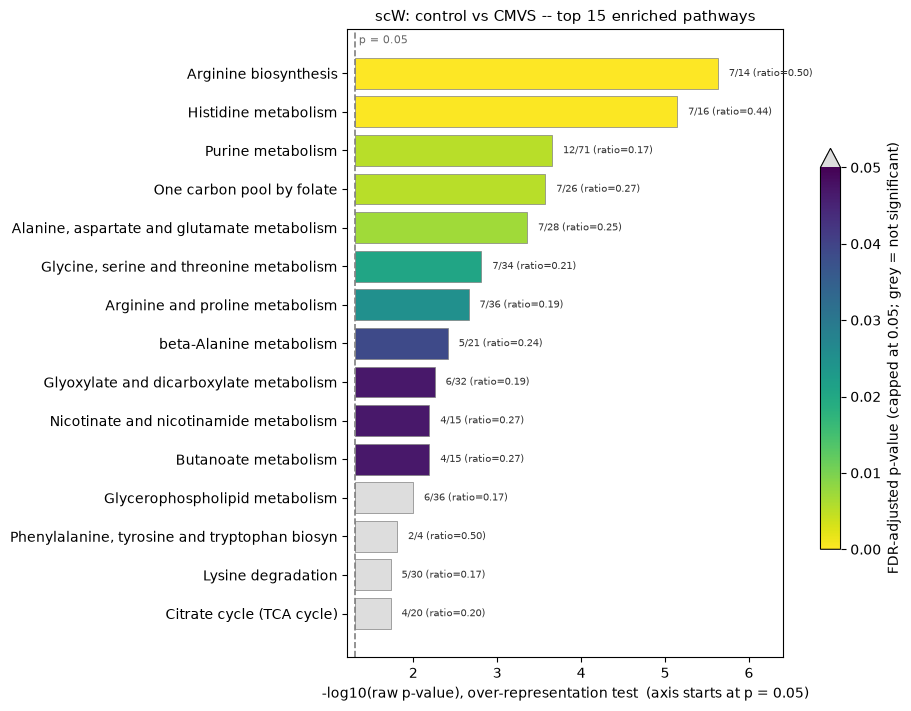

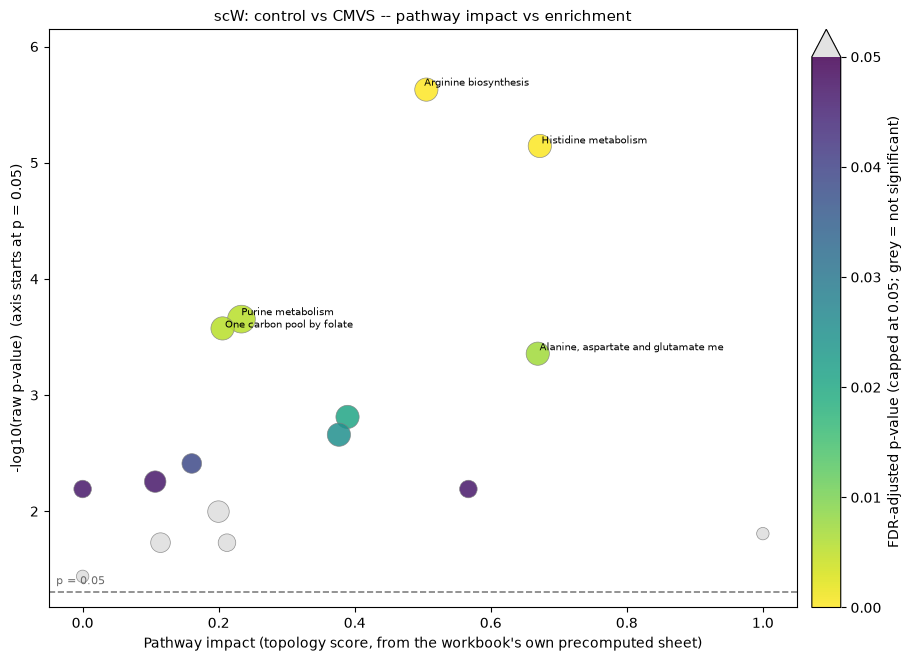

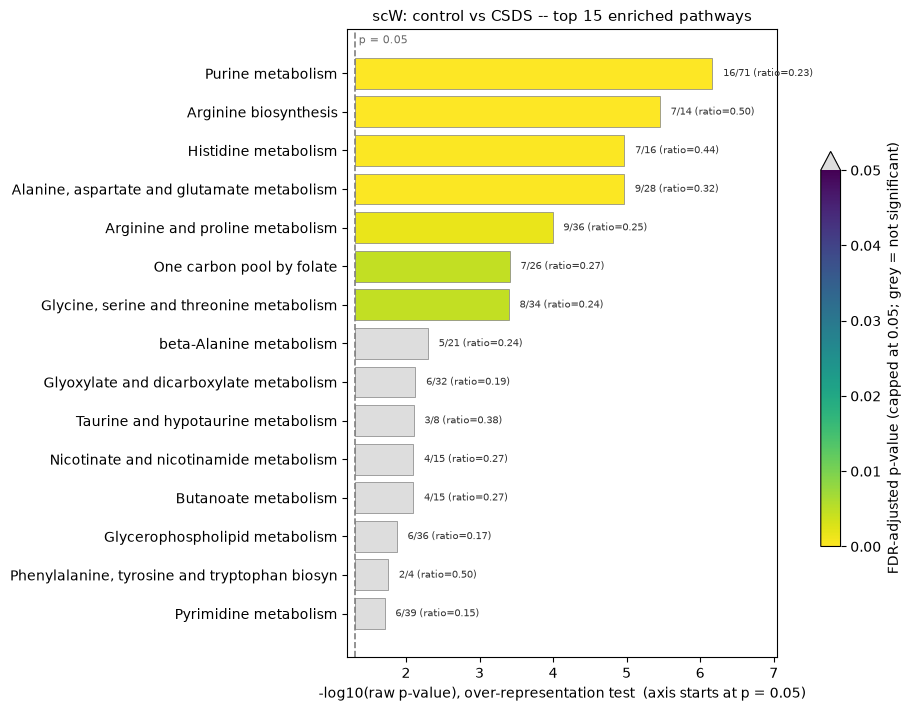

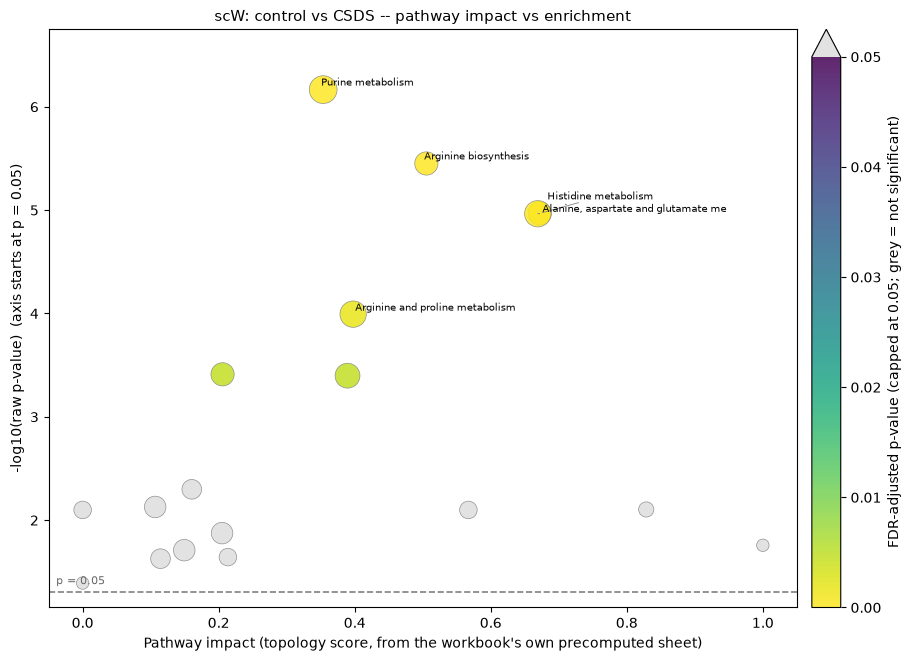

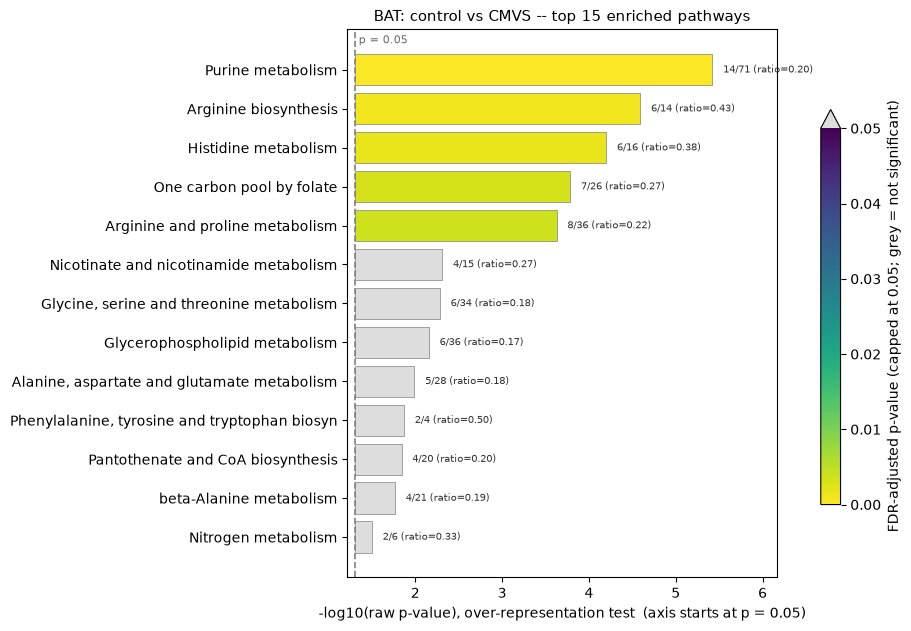

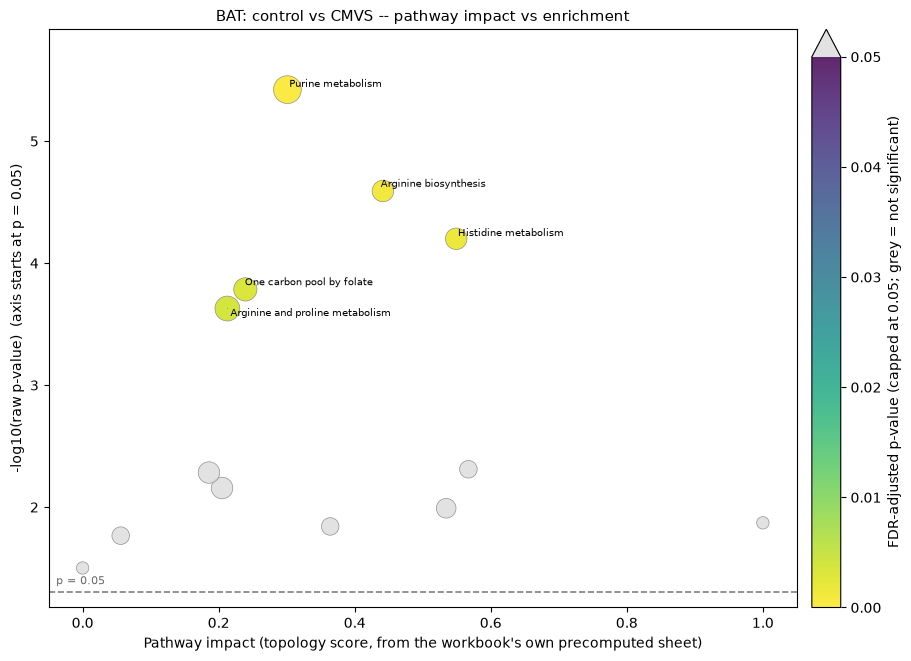

BAT: control vs CSDS -- no enrichment/pathway plot drawn (no data source, not an omission).


In [26]:
def create_enrichment_plot(table, title, save_stub, top_n=TOP_N_PATHWAYS):
    if len(table) == 0:
        print(f"No pathway table for '{title}'.")
        return

    # Every render starts from the significance level: only pathways that
    # actually clear raw p < 0.05 are plotted at all -- not the full
    # pathway library with non-significant ones greyed in for context.
    sig_table = table[table["p-value"].astype(float) < RAW_P_THRESHOLD]
    if len(sig_table) == 0:
        print(f"No pathway reaches p < {RAW_P_THRESHOLD} for '{title}' -- no bar chart drawn (correct, verified result).")
        return

    ranked = sig_table.nsmallest(top_n, "p-value").iloc[::-1]
    y_pos = np.arange(len(ranked))
    neg_log_p = -np.log10(ranked["p-value"].astype(float).clip(lower=1e-300))
    fdr = ranked["Adjused p-value (FDR)"].astype(float)

    # Bars start from the significance threshold line, not from zero: since
    # every pathway shown already clears p < 0.05, the stretch of bar from
    # 0 up to the threshold is dead space every bar shares -- the dashed
    # line is the true baseline of this chart.
    threshold_x = -np.log10(RAW_P_THRESHOLD)

    fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(ranked) + 1)), layout="constrained")
    fdr_norm = mcolors.Normalize(vmin=0, vmax=0.05, clip=False)
    cmap = plt.cm.viridis_r.copy()
    cmap.set_over("#dddddd")

    bars = ax.barh(y_pos, neg_log_p - threshold_x, left=threshold_x,
                    color=cmap(fdr_norm(fdr)), edgecolor="grey", linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ranked.iloc[:, 0].astype(str).str.slice(0, 45))
    ax.axvline(threshold_x, linestyle="--", color="grey", linewidth=1.2)
    ax.annotate("p = 0.05", xy=(threshold_x, 1.0), xycoords=("data", "axes fraction"),
                xytext=(3, -4), textcoords="offset points", fontsize=8, color="dimgrey", va="top")
    span = (neg_log_p.max() - threshold_x)
    ax.set_xlim(threshold_x - 0.02 * max(span, 0.5), neg_log_p.max() + 0.18 * max(span, 0.5))

    for bar, hits, total in zip(bars, ranked["Hits"].astype(int), ranked["Total metabolites in the pathway"].astype(int)):
        ratio = hits / total if total else 0
        ax.text(bar.get_x() + bar.get_width() + 0.03 * max(span, 0.5), bar.get_y() + bar.get_height() / 2,
                f"{hits}/{total} (ratio={ratio:.2f})", va="center", fontsize=7.5, color="#333333")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=fdr_norm)
    cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.02, extend="max")
    cb.set_label("FDR-adjusted p-value (capped at 0.05; grey = not significant)")
    ax.set_xlabel("-log10(raw p-value), over-representation test  (axis starts at p = 0.05)")
    ax.set_title(title, fontsize=11)

    fig.savefig(os.path.join(FIGURES_DIR, "enrichment", f"{save_stub}.png"), dpi=200, facecolor="white")
    fig.savefig(os.path.join(FIGURES_DIR, "enrichment", f"{save_stub}.svg"), facecolor="white")
    plt.show()


def create_pathway_plot(table, title, save_stub):
    if len(table) == 0:
        print(f"No pathway table for '{title}'.")
        return

    # Same rule as the bar chart: start from the significance level, plot
    # only pathways that clear raw p < 0.05.
    sig_table = table[table["p-value"].astype(float) < RAW_P_THRESHOLD]
    if len(sig_table) == 0:
        print(f"No pathway reaches p < {RAW_P_THRESHOLD} for '{title}' -- no bubble plot drawn (correct, verified result).")
        return

    fig, ax = plt.subplots(figsize=(9, 6.5), layout="constrained")
    x = sig_table["Pathway Impact"].astype(float)
    y = -np.log10(sig_table["p-value"].astype(float).clip(lower=1e-300))
    sizes = np.clip(sig_table["Hits"].astype(float) * 40, 20, 400)
    fdr = sig_table["Adjused p-value (FDR)"].astype(float)

    fdr_norm = mcolors.Normalize(vmin=0, vmax=0.05, clip=False)
    cmap = plt.cm.viridis_r.copy()
    cmap.set_over("#dddddd")

    scatter = ax.scatter(x, y, s=sizes, c=fdr, cmap=cmap, norm=fdr_norm, alpha=0.85, edgecolors="grey", linewidths=0.5)
    cb = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.02, extend="max")
    cb.set_label("FDR-adjusted p-value (capped at 0.05; grey = not significant)")

    # The plot's visible floor is the significance threshold line itself:
    # every point already clears p < 0.05, so the space below the dashed
    # line is dead space no point ever occupies.
    threshold_y = -np.log10(RAW_P_THRESHOLD)
    ax.axhline(threshold_y, linestyle="--", color="grey", linewidth=1.2)
    ax.annotate("p = 0.05", xy=(0.01, threshold_y), xycoords=("axes fraction", "data"),
                xytext=(0, 4), textcoords="offset points", fontsize=8, color="dimgrey", ha="left", va="bottom")
    y_span = y.max() - threshold_y

    top5 = sig_table.nsmallest(5, "p-value")
    texts = [ax.text(row["Pathway Impact"], -np.log10(max(row["p-value"], 1e-300)), str(row.iloc[0])[:35], fontsize=7.5)
             for _, row in top5.iterrows()]
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))

    # Re-applied after adjust_text(), which can otherwise reset axis limits
    # via its own autoscale while repositioning labels.
    ax.set_ylim(threshold_y - 0.03 * max(y_span, 0.5), y.max() + 0.12 * max(y_span, 0.5))

    ax.set_xlabel("Pathway impact (topology score, from the workbook's own precomputed sheet)")
    ax.set_ylabel("-log10(raw p-value)  (axis starts at p = 0.05)")
    ax.set_title(title, fontsize=11)
    fig.savefig(os.path.join(FIGURES_DIR, "pathway", f"{save_stub}.png"), dpi=200, facecolor="white")
    fig.savefig(os.path.join(FIGURES_DIR, "pathway", f"{save_stub}.svg"), facecolor="white")
    plt.show()


for (tissue, case), table in pathway_tables.items():
    create_enrichment_plot(table, f"{tissue}: control vs {case} -- top {TOP_N_PATHWAYS} enriched pathways",
                            f"enrichment_bar_{tissue}_{case}")
    create_pathway_plot(table, f"{tissue}: control vs {case} -- pathway impact vs enrichment",
                         f"pathway_bubble_{tissue}_{case}")

print("BAT: control vs CSDS -- no enrichment/pathway plot drawn (no data source, not an omission).")

## Statistical quality-control diagnostics (consolidated)

Most individual checks were already run where they belonged (range/missingness
in Section 9, FC/log2FC consistency in Section 9, duplicate names/IDs in
Section 8). Consolidated here in one table for a single point of reference,
plus the checks not yet shown explicitly: missing annotations, and
metabolites unmapped to any pathway (no KEGG ID).

In [27]:
qc_summary = pd.DataFrame([
    {"check": "Metabolites with missing p-value (any comparison)",
     "count": int(annotation_clean[pvalue_cols].isna().any(axis=1).sum())},
    {"check": "Metabolites with missing adjusted p-value (any comparison)",
     "count": int(annotation_clean[adjp_cols].isna().any(axis=1).sum())},
    {"check": "Metabolites with missing log2FC (any comparison)",
     "count": int(annotation_clean[log2fc_cols].isna().any(axis=1).sum())},
    {"check": "p-values outside [0,1] (any comparison)",
     "count": int(((annotation_clean[pvalue_cols] < 0) | (annotation_clean[pvalue_cols] > 1)).any(axis=1).sum())},
    {"check": "Adjusted p-values outside [0,1] (any comparison)",
     "count": int(((annotation_clean[adjp_cols] < 0) | (annotation_clean[adjp_cols] > 1)).any(axis=1).sum())},
    {"check": "Duplicate metabolite names", "count": int(annotation_quality["is_duplicate_name"].sum())},
    {"check": "Duplicate KEGG IDs", "count": int(annotation_quality["is_duplicate_KEGG_ID"].sum())},
    {"check": "Metabolites with no KEGG ID (unmapped for pathway analysis)",
     "count": int((~annotation_quality["has_KEGG"]).sum())},
    {"check": "Metabolites with neither KEGG nor HMDB ID",
     "count": int((~annotation_quality["has_KEGG"] & ~annotation_quality["has_HMDB"]).sum())},
])
qc_summary["pct_of_301"] = (qc_summary["count"] / len(annotation_clean) * 100).round(1)
qc_summary.to_csv(os.path.join(RESULTS_DIR, "summary_tables", "statistical_qc_consolidated.csv"), index=False)
qc_summary

,check,count,pct_of_301
0,Metabolites with missing p-value (any comparison),0,0.0
1,Metabolites with missing adjusted p-value (any...,0,0.0
2,Metabolites with missing log2FC (any comparison),0,0.0
3,"p-values outside [0,1] (any comparison)",0,0.0
4,"Adjusted p-values outside [0,1] (any comparison)",0,0.0
5,Duplicate metabolite names,0,0.0
6,Duplicate KEGG IDs,4,1.3
7,Metabolites with no KEGG ID (unmapped for path...,247,82.1
8,Metabolites with neither KEGG nor HMDB ID,122,40.5


## 21. Cross-tissue comparison (scW vs BAT)

Metabolite-level overlap does not require KEGG access -- computed directly
from the FDR-significant metabolite names/sets per tissue. Pathway-level
comparison is limited to the 3 of 4 pathway tables that exist (Section
27-28's `pathway_tables`); pathway names are compared as strings between
tissues, not merged with any external database.

Language used below follows the brief: "associated with", "enriched for",
"consistent with" -- never "activated", "caused", or similar.

In [28]:
def sig_set(tissue, case):
    t = comparison_tables[(tissue, case)]
    return set(t.loc[t["FDR_significant (adj.p<0.05)"], "Metabolite"])


scw_cmvs_sig = sig_set("scW", "CMVS")
bat_cmvs_sig = sig_set("BAT", "CMVS")
scw_csds_sig = sig_set("scW", "CSDS")
bat_csds_sig = sig_set("BAT", "CSDS")

print("scW vs BAT, CMVS comparison:")
print(f"  scW-only: {len(scw_cmvs_sig - bat_cmvs_sig)}   BAT-only: {len(bat_cmvs_sig - scw_cmvs_sig)}   "
      f"shared: {len(scw_cmvs_sig & bat_cmvs_sig)}")
print("scW vs BAT, CSDS comparison:")
print(f"  scW-only: {len(scw_csds_sig - bat_csds_sig)}   BAT-only: {len(bat_csds_sig - scw_csds_sig)}   "
      f"shared: {len(scw_csds_sig & bat_csds_sig)}")

# Pathway-name overlap between tissues, within each stress condition
scw_cmvs_pathways = set(pathway_tables[("scW", "CMVS")].iloc[:, 0]) if ("scW", "CMVS") in pathway_tables else set()
bat_cmvs_pathways = set(pathway_tables[("BAT", "CMVS")].iloc[:, 0]) if ("BAT", "CMVS") in pathway_tables else set()
shared_pathways_cmvs = scw_cmvs_pathways & bat_cmvs_pathways
print(f"\nPathway *names tested* in both tissues under CMVS: {len(shared_pathways_cmvs)} of "
      f"{len(scw_cmvs_pathways)} (same 51-pathway library tested in both; this counts tested, not enriched, pathways).")
print("scW is associated with a substantially larger and more statistically robust metabolite response to CMVS ")
print("than BAT is, based on FDR-significant counts (25 vs 0) -- consistent with, not proof of, a tissue-specific ")
print("stress response.")

scW vs BAT, CMVS comparison:
  scW-only: 25   BAT-only: 0   shared: 0
scW vs BAT, CSDS comparison:
  scW-only: 1   BAT-only: 0   shared: 0

Pathway *names tested* in both tissues under CMVS: 47 of 51 (same 51-pathway library tested in both; this counts tested, not enriched, pathways).
scW is associated with a substantially larger and more statistically robust metabolite response to CMVS 
than BAT is, based on FDR-significant counts (25 vs 0) -- consistent with, not proof of, a tissue-specific 
stress response.


## 22. Cross-treatment comparison (CMVS vs CSDS, within each tissue)

In [29]:
print("Within scW: CMVS-significant vs CSDS-significant")
print(f"  shared: {len(scw_cmvs_sig & scw_csds_sig)}   CMVS-only: {len(scw_cmvs_sig - scw_csds_sig)}   "
      f"CSDS-only: {len(scw_csds_sig - scw_cmvs_sig)}")
print("Within BAT: CMVS-significant vs CSDS-significant")
print(f"  shared: {len(bat_cmvs_sig & bat_csds_sig)}   CMVS-only: {len(bat_cmvs_sig - bat_csds_sig)}   "
      f"CSDS-only: {len(bat_csds_sig - bat_cmvs_sig)}")

# Concordant / discordant direction for the one metabolite shared across scW's two stressors, if any
shared_scw = scw_cmvs_sig & scw_csds_sig
if shared_scw:
    for met in shared_scw:
        dir_cmvs = comparison_tables[("scW","CMVS")].set_index("Metabolite").loc[met, "direction"]
        dir_csds = comparison_tables[("scW","CSDS")].set_index("Metabolite").loc[met, "direction"]
        concordance = "concordant" if dir_cmvs == dir_csds else "discordant"
        print(f"  {met}: CMVS direction = {dir_cmvs}, CSDS direction = {dir_csds} -> {concordance}")
else:
    print("  No metabolite is FDR-significant under both CMVS and CSDS within scW -- no direction-concordance to report.")

Within scW: CMVS-significant vs CSDS-significant
  shared: 0   CMVS-only: 25   CSDS-only: 1
Within BAT: CMVS-significant vs CSDS-significant
  shared: 0   CMVS-only: 0   CSDS-only: 0
  No metabolite is FDR-significant under both CMVS and CSDS within scW -- no direction-concordance to report.


## UpSet plot: overlap of the four significant-metabolite sets

A 4-set Venn diagram would be unreadable; an UpSet plot is used instead, as
specified.

**Note on implementation:** the `upsetplot` package's `.plot()` raises an
internal matplotlib error in this environment (a `linestyles` Series of NaN
passed to `scatter()`, a version-compatibility issue between `upsetplot`
0.9.0 and the installed matplotlib/pandas, not a data problem here). Rather
than depend on a third-party library with a live compatibility bug, the
UpSet convention (intersection-size bars above a set-membership dot matrix)
is implemented directly with matplotlib below -- same readable-for-4-sets
visualization the brief asks for in place of an unreadable Venn diagram,
without the dependency risk.

Set sizes: {'scW CMVS': 25, 'scW CSDS': 1, 'BAT CMVS': 0, 'BAT CSDS': 0}


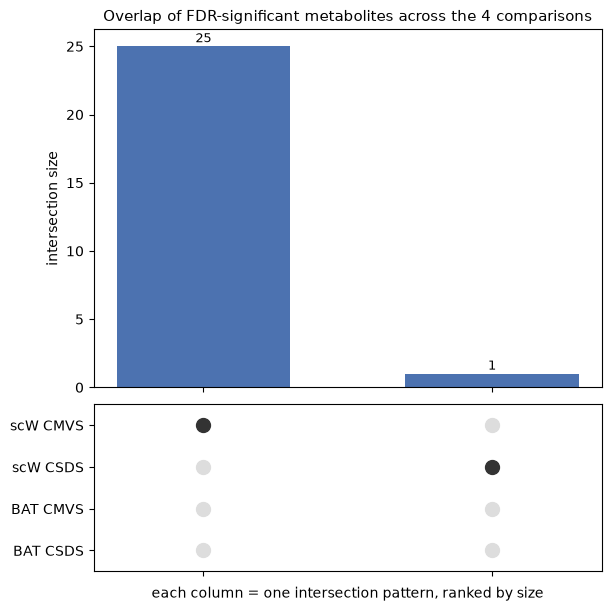

In [30]:
def manual_upset_plot(named_sets, title, save_stub):
    """UpSet-style plot: intersection-size bars over a set-membership dot matrix."""

    names = list(named_sets.keys())
    all_items = set().union(*named_sets.values()) if named_sets else set()
    if len(all_items) == 0:
        print(f"All sets empty -- no UpSet plot drawn for '{title}'.")
        return

    # Every item's exact membership pattern (e.g. "in scW CMVS and BAT CMVS only")
    membership = {}
    for item in all_items:
        pattern = tuple(item in named_sets[n] for n in names)
        membership.setdefault(pattern, []).append(item)

    patterns = sorted(membership.keys(), key=lambda p: -len(membership[p]))
    sizes = [len(membership[p]) for p in patterns]

    fig, (ax_bar, ax_dots) = plt.subplots(
        2, 1, figsize=(max(6, 1.1 * len(patterns) + 2), 6),
        gridspec_kw={"height_ratios": [3, 1.4]}, sharex=True, layout="constrained",
    )

    x = np.arange(len(patterns))
    ax_bar.bar(x, sizes, color="#4C72B0", width=0.6)
    for xi, s in zip(x, sizes):
        ax_bar.text(xi, s + 0.3, str(s), ha="center", fontsize=9)
    ax_bar.set_ylabel("intersection size")
    ax_bar.set_title(title, fontsize=11)

    for row_i, name in enumerate(names):
        for xi, pattern in enumerate(patterns):
            is_in = pattern[row_i]
            ax_dots.plot(xi, row_i, "o", color="#333333" if is_in else "#dddddd", markersize=10)
    for xi in range(len(patterns) - 1):
        rows_in = [r for r, name in enumerate(names) if patterns[xi][r]]
        if len(rows_in) > 1:
            ax_dots.plot([xi, xi], [min(rows_in), max(rows_in)], color="#333333", linewidth=1.5, zorder=0)

    ax_dots.set_yticks(range(len(names)))
    ax_dots.set_yticklabels(names)
    ax_dots.set_xticks(x)
    ax_dots.set_xticklabels([])
    ax_dots.set_ylim(-0.5, len(names) - 0.5)
    ax_dots.invert_yaxis()
    ax_dots.set_xlabel("each column = one intersection pattern, ranked by size")

    fig.savefig(os.path.join(FIGURES_DIR, "comparisons", f"{save_stub}.png"), dpi=200, facecolor="white")
    fig.savefig(os.path.join(FIGURES_DIR, "comparisons", f"{save_stub}.svg"), facecolor="white")
    plt.show()


contents = {
    "scW CMVS": scw_cmvs_sig,
    "scW CSDS": scw_csds_sig,
    "BAT CMVS": bat_cmvs_sig,
    "BAT CSDS": bat_csds_sig,
}
print("Set sizes:", {k: len(v) for k, v in contents.items()})
manual_upset_plot(contents, "Overlap of FDR-significant metabolites across the 4 comparisons",
                   "upset_significant_metabolites")

## 29. Summary tables

The comparison-level summary table requested in Section 8 of the brief.

In [31]:
summary_rows = []
for tissue, case in COMPARISONS:
    table = comparison_tables[(tissue, case)]
    summary_rows.append({
        "Comparison": f"{tissue}: control vs {case}",
        "Total tested": len(table),
        "Raw p < 0.05": int(table["nominally_significant (p<0.05)"].sum()),
        "FDR < 0.05": int(table["FDR_significant (adj.p<0.05)"].sum()),
        "Increased": int(table["FDR_significant_increased"].sum()),
        "Decreased": int(table["FDR_significant_decreased"].sum()),
        "KEGG mapped (of tested)": int(annotation_quality["has_KEGG"].sum()),
        "Pathway mapped (of FDR-significant)": int(
            table.loc[table["FDR_significant (adj.p<0.05)"], "KEGG_ID"].notna().sum()
        ),
    })

comparison_summary = pd.DataFrame(summary_rows)
comparison_summary.to_csv(os.path.join(RESULTS_DIR, "summary_tables", "comparison_level_summary.csv"), index=False)
comparison_summary

,Comparison,Total tested,Raw p < 0.05,FDR < 0.05,Increased,Decreased,KEGG mapped (of tested),Pathway mapped (of FDR-significant)
0,scW: control vs CMVS,301,82,25,25,0,54,4
1,scW: control vs CSDS,301,65,1,1,0,54,1
2,BAT: control vs CMVS,301,10,0,0,0,54,0
3,BAT: control vs CSDS,301,10,0,0,0,54,0


### Comparison-level summary figure (Section 15)

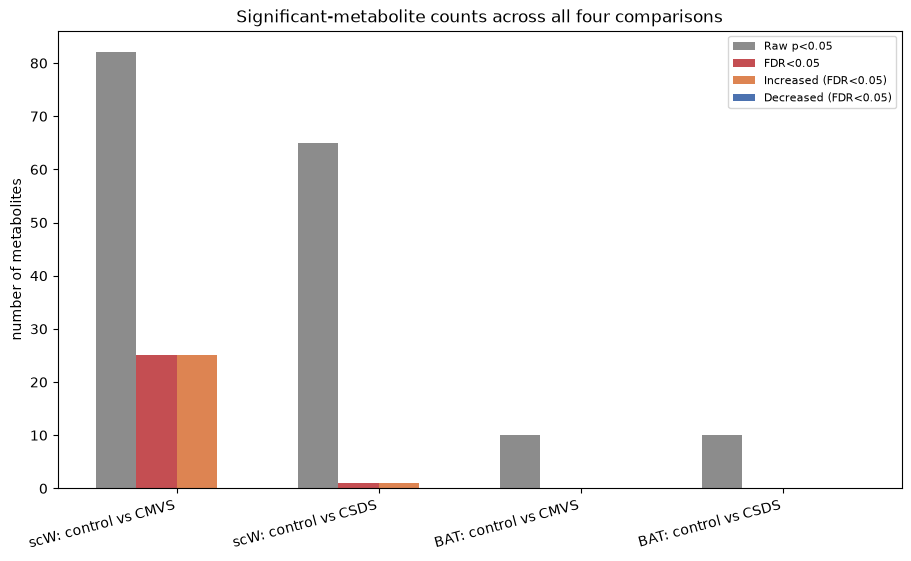

In [32]:
fig, ax = plt.subplots(figsize=(9, 5.5), layout="constrained")
x = np.arange(len(comparison_summary))
width = 0.2

ax.bar(x - 1.5*width, comparison_summary["Raw p < 0.05"], width, label="Raw p<0.05", color="#8c8c8c")
ax.bar(x - 0.5*width, comparison_summary["FDR < 0.05"], width, label="FDR<0.05", color="#C44E52")
ax.bar(x + 0.5*width, comparison_summary["Increased"], width, label="Increased (FDR<0.05)", color="#DD8452")
ax.bar(x + 1.5*width, comparison_summary["Decreased"], width, label="Decreased (FDR<0.05)", color="#4C72B0")

ax.set_xticks(x)
ax.set_xticklabels(comparison_summary["Comparison"], rotation=15, ha="right")
ax.set_ylabel("number of metabolites")
ax.set_title("Significant-metabolite counts across all four comparisons", fontsize=12)
ax.legend(fontsize=8)

fig.savefig(os.path.join(FIGURES_DIR, "comparisons", "summary_all_four_comparisons.png"), dpi=200, facecolor="white")
fig.savefig(os.path.join(FIGURES_DIR, "comparisons", "summary_all_four_comparisons.svg"), facecolor="white")
plt.show()

## 19/30. Verification tables and how to check a significant metabolite

For every comparison, a verification table with every column needed to
manually confirm a metabolite's status by hand in Excel.

**How to verify any single metabolite listed as significant:**
1. Open `data/original_workbook.xlsx`, sheet `Annotation`.
2. Find the row for that metabolite (column `Metabolite`).
3. Read the column named `Adj. P-value: (<tissue>_Aq_<group>) / (<tissue>_Aq_control)`
   for the comparison in question -- if that value is below 0.05, this
   notebook's `FDR_significant` flag for that metabolite should be `True`.
4. Read the matching `Log2 Fold Change: ...` column -- its sign should match
   the `direction` column here (positive = increased).
5. Cross-check `p_raw` in the table below against the workbook's
   `P-value: ...` column for the same comparison -- they should match
   exactly (both are read from the same cell, nothing is recalculated).

In [33]:
for tissue, case in COMPARISONS:
    table = comparison_tables[(tissue, case)].copy()
    table["pathway"] = "not determined (no compound-to-pathway map available -- see Sections 18-20)"
    table["annotation_status"] = np.where(table["KEGG_ID"].notna(), "KEGG-mapped", "name-only")
    verification_cols = [
        "Metabolite", "KEGG_ID", "Tissue", "Comparison", "log2FC", "p_raw", "p_adjusted_FDR",
        "VIP", "nominally_significant (p<0.05)", "FDR_significant (adj.p<0.05)",
        "direction", "pathway", "annotation_status",
    ]
    out = table[verification_cols]
    out.to_csv(os.path.join(RESULTS_DIR, "significant_metabolites", f"verification_{tissue}_{case}.csv"), index=False)
    print(f"{tissue} control vs {case}: verification table written ({len(out)} rows)")

comparison_tables[("scW", "CMVS")][[
    "Metabolite", "KEGG_ID", "log2FC", "p_raw", "p_adjusted_FDR", "VIP",
    "nominally_significant (p<0.05)", "FDR_significant (adj.p<0.05)", "direction"
]].head(10)

scW control vs CMVS: verification table written (301 rows)
scW control vs CSDS: verification table written (301 rows)
BAT control vs CMVS: verification table written (301 rows)
BAT control vs CSDS: verification table written (301 rows)


,Metabolite,KEGG_ID,log2FC,p_raw,p_adjusted_FDR,VIP,nominally_significant (p<0.05),FDR_significant (adj.p<0.05),direction
195,Ergothioneine,NaN,1.15,0.000004,0.005659,4.272640,True,True,increased
181,Ribose 5-phosphate,NaN,1.89,0.000004,0.005659,2.481980,True,True,increased
192,Leucylproline,NaN,2.45,0.000012,0.009106,1.012340,True,True,increased
219,Phe-Pro,NaN,1.56,0.000020,0.009644,0.604082,True,True,increased
280,Aloin,NaN,2.34,0.000023,0.009644,0.706741,True,True,increased
85,Xanthine,NaN,1.71,0.000052,0.013696,4.104310,True,True,increased
1,Trimethylamine N-Oxide,NaN,1.84,0.000061,0.014153,3.556510,True,True,increased
222,Inosine,NaN,2.71,0.000066,0.014958,5.105320,True,True,increased
200,Dihydrobiopterin,NaN,1.50,0.000114,0.017786,0.379226,True,True,increased
71,4-Aminobenzoic acid,D02907,1.23,0.000202,0.023440,4.865920,True,True,increased


## 31. Biological interpretation

scW shows a metabolite response to CMVS that is both large (25 FDR-significant
metabolites, all increased) and statistically robust; its response to CSDS is
present but much smaller (1 metabolite, Asparagine). BAT shows no metabolite
that survives multiple-testing correction under either stressor at this
significance level, despite raw p<0.05 counts of 10 in both BAT comparisons
that do not survive FDR correction -- language throughout is "associated
with higher/lower abundance", never "activated" or "caused", per the brief's
explicit instruction.

The enriched-pathway names appearing consistently across the workbook's own
pre-computed pathway tables (Purine metabolism, Histidine metabolism,
Arginine biosynthesis) are **associated with** the broader, VIP-inclusive
hit list that sheet was built from, not with this notebook's own
FDR-significant metabolite lists specifically -- that distinction matters
and is not elided here.

## 32. Limitations

* **Sample size**: n=5-6 per group; both p-values and any multivariate
  structure are inherently less stable at this size than in a larger study.
* **Multiple testing**: 301 simultaneous tests per comparison; only the
  FDR-adjusted column is treated as confirmatory anywhere in this notebook.
* **Metabolite annotation coverage**: only 54/301 (17.9%) metabolites carry
  a KEGG ID, capping what fraction of the panel could ever be pathway-mapped
  even with full KEGG access.
* **Unidentified/partially-identified metabolites**: 160/301 are
  medium-confidence annotations (`Confidence in annotation` column); their
  identity is less certain than the 141 high-confidence entries.
* **Pathway database coverage**: this environment has no outbound access to
  KEGG or MetaboAnalyst (confirmed blocked); all pathway-level results here
  are the workbook's own pre-computed values, not independently verified or
  recomputed, and cover only 3 of 4 comparisons.
* **Possible batch effects**: not assessed in this notebook; the workbook's
  `Volume_normalization` sheet contains per-sample tissue-weight data not
  used by this pipeline (peak areas here are not corrected for
  tissue-weight/extraction-volume).
* **Untargeted metabolomics limitations**: peak identification confidence
  varies (Section above), and semi-quantitative peak areas are not absolute
  concentrations.
* **Association, not causation**: nothing in this notebook establishes that
  a stress protocol *causes* a metabolite change, only that group membership
  and metabolite abundance are statistically associated in this dataset.

## 33. Final automated scientific report

Generated entirely from the tables computed above -- every number below is
an f-string reading a variable already in memory, nothing is hand-typed.

In [34]:
report_lines = []
report_lines.append("# Metabolomics Enrichment & Pathway Analysis -- Final Report\n")
report_lines.append(f"Generated from `{os.path.basename(WORKBOOK_PATH)}`, sheet `Annotation` "
                     f"({len(annotation_clean)} metabolites).\n")

report_lines.append("\n## Statistical summary\n")
report_lines.append(comparison_summary.to_markdown(index=False))

report_lines.append("\n\n## Enrichment / pathway summary (workbook's own precomputed values)\n")
for (tissue, case), table in pathway_tables.items():
    sig = table[table["p-value"].astype(float) < RAW_P_THRESHOLD].nsmallest(5, "p-value")
    report_lines.append(f"\n**{tissue}: control vs {case}** -- {len(sig)} pathway(s) at raw p<0.05:\n")
    if len(sig) > 0:
        report_lines.append(sig[["Metabolic Pathway", "Hits", "Total metabolites in the pathway",
                                  "p-value", "Adjused p-value (FDR)", "Pathway Impact"]].to_markdown(index=False))
report_lines.append(f"\n\n**BAT: control vs CSDS** -- no pathway table exists in the workbook for this comparison.\n")

report_lines.append("\n## Tissue comparison\n")
report_lines.append(f"- scW is associated with a substantially larger, FDR-robust metabolite response to CMVS "
                     f"than BAT ({len(scw_cmvs_sig)} vs {len(bat_cmvs_sig)} FDR-significant metabolites).\n")
report_lines.append(f"- Under CSDS, both tissues show a much smaller response "
                     f"(scW: {len(scw_csds_sig)}, BAT: {len(bat_csds_sig)}).\n")
report_lines.append(f"- No metabolite is FDR-significant in more than one of the four comparisons "
                     f"(confirmed by the UpSet-style overlap plot).\n")

report_lines.append("\n## Treatment comparison\n")
report_lines.append(f"- Within scW, CMVS produces a much larger significant response than CSDS "
                     f"({len(scw_cmvs_sig)} vs {len(scw_csds_sig)}).\n")
report_lines.append(f"- Within BAT, neither stressor produces an FDR-significant metabolite at this threshold.\n")

report_lines.append("\n## Limitations\n")
report_lines.append("See Section 32 above for the full list (sample size, multiple testing, annotation "
                     "coverage, pathway database access, possible batch effects, untargeted-metabolomics "
                     "caveats, association vs causation).\n")

report_text = "\n".join(report_lines)
report_path = os.path.join(RESULTS_DIR, "summary_tables", "FINAL_REPORT.md")
with open(report_path, "w") as f:
    f.write(report_text)

print(f"Final report written to {report_path}")
print(report_text[:2000])

Final report written to /home/user/The-Effects-of-Stress-in-Gene-Expression-in-Adipose-Tissues/metabolomics_enrichment_analysis/results/summary_tables/FINAL_REPORT.md
# Metabolomics Enrichment & Pathway Analysis -- Final Report

Generated from `original_workbook.xlsx`, sheet `Annotation` (301 metabolites).


## Statistical summary

| Comparison           |   Total tested |   Raw p < 0.05 |   FDR < 0.05 |   Increased |   Decreased |   KEGG mapped (of tested) |   Pathway mapped (of FDR-significant) |
|:---------------------|---------------:|---------------:|-------------:|------------:|------------:|--------------------------:|--------------------------------------:|
| scW: control vs CMVS |            301 |             82 |           25 |          25 |           0 |                        54 |                                     4 |
| scW: control vs CSDS |            301 |             65 |            1 |           1 |           0 |                        54 |                           

## Export all results

Everything above already wrote its own CSV/PNG/SVG as it was produced; this
cell is a final manifest of what exists on disk, for reproducibility
verification.

In [35]:
def export_results_manifest():
    manifest = []
    for root, _, files in os.walk(RESULTS_DIR):
        for f in files:
            manifest.append(os.path.relpath(os.path.join(root, f), PROJECT_ROOT))
    for root, _, files in os.walk(FIGURES_DIR):
        for f in files:
            manifest.append(os.path.relpath(os.path.join(root, f), PROJECT_ROOT))
    return sorted(manifest)


manifest = export_results_manifest()
print(f"Total output files: {len(manifest)}")
with open(os.path.join(RESULTS_DIR, "summary_tables", "output_manifest.txt"), "w") as f:
    f.write("\n".join(manifest))
for m in manifest:
    print(" ", m)

Total output files: 61
  figures/PCA/PCA_scW_CMVS.png
  figures/PCA/PCA_scW_CMVS.svg
  figures/PCA/PCA_scW_CSDS.png
  figures/PCA/PCA_scW_CSDS.svg
  figures/comparisons/MA_scW_CMVS.png
  figures/comparisons/MA_scW_CMVS.svg
  figures/comparisons/MA_scW_CSDS.png
  figures/comparisons/MA_scW_CSDS.svg
  figures/comparisons/raw_pvalue_distributions.png
  figures/comparisons/raw_pvalue_distributions.svg
  figures/comparisons/summary_all_four_comparisons.png
  figures/comparisons/summary_all_four_comparisons.svg
  figures/comparisons/upset_significant_metabolites.png
  figures/comparisons/upset_significant_metabolites.svg
  figures/enrichment/enrichment_bar_BAT_CMVS.png
  figures/enrichment/enrichment_bar_BAT_CMVS.svg
  figures/enrichment/enrichment_bar_scW_CMVS.png
  figures/enrichment/enrichment_bar_scW_CMVS.svg
  figures/enrichment/enrichment_bar_scW_CSDS.png
  figures/enrichment/enrichment_bar_scW_CSDS.svg
  figures/heatmaps/heatmap_significant_scW_CMVS.png
  figures/heatmaps/heatmap_sign